## 1.&nbsp; Get the info of the Data Sets

In [68]:
import os
import pandas as pd

### Data frames information 
First, let's create the dataframes from our **clean data**:

In [69]:
# Define Data Directory (new step that could have reduce long paths afterwards)
data_dir = r"C:\Users\msnch\OneDrive\Bootcamp\Eniacs_Discount\2_clean"

In [70]:
brands_cl = pd.read_csv(r"C:\Users\msnch\OneDrive\Bootcamp\Eniacs_Discount\2_clean\brands_clean.csv")
orderlines_cl = pd.read_csv(r"C:\Users\msnch\OneDrive\Bootcamp\Eniacs_Discount\2_clean\orderlines_clean.csv")
orders_cl = pd.read_csv(r"C:\Users\msnch\OneDrive\Bootcamp\Eniacs_Discount\2_clean\orders_clean.csv")
products_cl = pd.read_csv(r"C:\Users\msnch\OneDrive\Bootcamp\Eniacs_Discount\2_clean\products_clean.csv")

## 2.&nbsp; Define Pandas Display Format

In [71]:
# Copy and save the dataframes
brands_df = brands_cl.copy()
orderlines_df = orderlines_cl.copy()
orders_df = orders_cl.copy()
products_df = products_cl.copy()

### 2.1.&nbsp; Include products categories

In [72]:
type_labels_df = pd.read_csv(
    os.path.join(data_dir, "type_labels.csv"),
    index_col="type_id"
)

products_df = products_df.join(
    type_labels_df,
    on="type"
)

### 2.2.&nbsp; Set the format

In [73]:
# Format
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

## 3.&nbsp; Let's ask some questions:
- What is the time period that the dataset covers?
- What is the overall revenue for that time?
- Are there seasonal patterns in the evolution of sales?
- What are the most sold products?
- What are the products that generate the most revenue?

In [74]:
# # Code here to explore values in the dataframes
# orders_df.info()
# orderlines_df.info()
products_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6886 entries, 0 to 6885
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku          6886 non-null   str    
 1   name         6886 non-null   str    
 2   desc         6886 non-null   str    
 3   price        6886 non-null   float64
 4   in_stock     6886 non-null   bool   
 5   type         6886 non-null   int64  
 6   category     6886 non-null   str    
 7   subcategory  6886 non-null   str    
dtypes: bool(1), float64(1), int64(1), str(5)
memory usage: 1.4 MB


In [75]:
# Range of date for orders
orders_df["created_date"] = pd.to_datetime(orders_df["created_date"])
orders_df["created_date"].agg(["min", "max"])

min   2017-01-01 01:51:47
max   2018-03-14 13:58:36
Name: created_date, dtype: datetime64[us]

In [76]:
# Range of date for order lines
orderlines_df["date"] = pd.to_datetime(orderlines_df["date"])
orderlines_df["date"].agg(["min", "max"])

min   2017-01-01 01:46:16
max   2018-03-14 13:58:36
Name: date, dtype: datetime64[us]

In [77]:
# Get unit_price total per order
orderlines_df.info()
orderlines_df["unit_price_total"] = orderlines_df["product_quantity"] * orderlines_df["unit_price"]
orderlines_df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 114711 entries, 0 to 114710
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                114711 non-null  int64         
 1   id_order          114711 non-null  int64         
 2   product_quantity  114711 non-null  int64         
 3   sku               114711 non-null  str           
 4   unit_price        114711 non-null  float64       
 5   date              114711 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(3), str(1)
memory usage: 6.0 MB


,id,id_order,product_quantity,sku,unit_price,date,unit_price_total
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,47.49
1,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,18.99
2,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,72.19
3,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,2565.99
4,1119131,299553,1,APP1854,3278.99,2017-01-01 02:14:47,3278.99
5,1119133,299555,1,BEA0065,256.49,2017-01-01 02:18:45,256.49
6,1119134,299556,1,CRU0039-A,60.90,2017-01-01 02:20:14,60.90
7,1119145,299561,1,PEB0015,142.49,2017-01-01 02:38:50,142.49
8,1119154,299563,1,BEA0065,256.49,2017-01-01 02:42:05,256.49
9,1119155,299564,1,SAT0010,18.99,2017-01-01 02:43:37,18.99


In [78]:
# Make a df with the sum of units
order_totals_df = orderlines_df.groupby("id_order")[["unit_price_total"]].sum()
order_totals_df = order_totals_df.reset_index()
order_totals_df["unit_price_total"].sum()

np.float64(37289611.94)

In [79]:
# Make a df with the sum of units
# orderlines_df.head()
products_df.head()

,sku,name,desc,price,in_stock,type,category,subcategory
0,8MO0001-A,Open - Micro SD Adapter 8Mobility iSlice Macbo...,Micro SD card adapter for MacBook Air 13-inch,35.00,False,1298,Accessories,Adapters & Hubs - Open Box
1,8MO0003-A,Open - 8Mobility iSlice Micro SD adapter for M...,Refurbished adapter Micro SD card for MacBook ...,35.00,False,12585395,Peripherals,USB Hubs & Adapters - Open Box
2,8MO0007,8Mobility iSlice Micro SD adapter for Macbook ...,Micro SD card adapter for MacBook Air 13-inch,35.00,False,12585395,Peripherals,USB Hubs & Adapters - Open Box
3,8MO0008,8Mobility iSlice Micro SD Adapter Macbook Pro ...,Micro SD card adapter for MacBook Pro Retina 1...,35.00,False,12585395,Peripherals,USB Hubs & Adapters - Open Box
4,8MO0009,8Mobility iSlice Micro SD Adapter for Macbook ...,Micro SD card adapter for MacBook Pro Retina 1...,35.00,True,12585395,Peripherals,USB Hubs & Adapters - Open Box


## 4.&nbsp;  Answers to the questions:
- The dataframes for orders and orderlines cover the same time (1 year, 3.5 months)
- The total revenue in this period time EUR37,289,611.94

2. How big are the offered discounts as a percentage of the product prices? --> Marco
Can we build percentage categories (for example, 0-10%, 10-25%, 25-50%)?

### 1.&nbsp; Identify which values to work with in each dataframe:

In [80]:
# orderlines_df.head()
orderlines_df.info()
orders_df.info()
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114711 entries, 0 to 114710
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   id                114711 non-null  int64         
 1   id_order          114711 non-null  int64         
 2   product_quantity  114711 non-null  int64         
 3   sku               114711 non-null  str           
 4   unit_price        114711 non-null  float64       
 5   date              114711 non-null  datetime64[us]
 6   unit_price_total  114711 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(3), str(1)
memory usage: 6.9 MB
<class 'pandas.DataFrame'>
RangeIndex: 89233 entries, 0 to 89232
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      89233 non-null  int64         
 1   created_date  89233 non-null  datetime64[us]
 2   total_paid    89233 non-nul

Yes. The cleanest approach is to treat products_df["price"] as the regular/list price and orderlines_df["unit_price"] as the actual selling price. Then calculate the discount at the order-line level after joining the product information onto orderlines_df.
The important thing is that you generally shouldn't use orders_df["total_paid"] to calculate product-level discounts. total_paid is at the whole-order level and may include shipping, multiple products, etc. It is useful later for validating your calculations.

### 2.&nbsp;  Merge products with order lines

In [81]:
discount_df = orderlines_df.merge(
    products_df[["sku","name","price"]], 
    on="sku",
    how='left'
)
discount_df.head()

,id,id_order,product_quantity,sku,unit_price,date,unit_price_total,name,price
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,47.49,OWC In-line Digital Temperature Sensor Kit HDD...,60.99
1,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,18.99,iOttie Easy View 2 Car Black Support,22.95
2,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,72.19,Apple 85W MagSafe 2 charger MacBook Pro screen...,89.00
3,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,2565.99,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",3209.00
4,1119131,299553,1,APP1854,3278.99,2017-01-01 02:14:47,3278.99,"Apple MacBook Pro 13 ""with Touch Bar 33GHz Cor...",3279.00


In [82]:
discount_df[["sku", "name", "price", "unit_price"]].isna().sum()

sku            0
name          56
price         56
unit_price     0
dtype: int64

In [83]:
# inspect these missing values
missing_price = discount_df[discount_df["price"].isna()]

missing_price[
    ["sku", "name", "price", "unit_price", "product_quantity"]
]
# missing_price["sku"].nunique() # 13 sku missing

,sku,name,price,unit_price,product_quantity
168,APP1482,NaN,NaN,549.00,1
1154,APP1188,NaN,NaN,879.00,1
1179,APP1480,NaN,NaN,489.00,1
1497,APP1483,NaN,NaN,549.00,1
2161,APP1478,NaN,NaN,489.00,1
2164,APP1478,NaN,NaN,489.00,1
2168,APP1478,NaN,NaN,489.00,1
3343,APP1188,NaN,NaN,726.45,1
3397,APP1188,NaN,NaN,726.45,4
5036,APP1479,NaN,NaN,489.00,1


The products with missing value are relatively expensive on the pricer per unit. Most of the "sku" starts with "APP" (could these be apps?)

In [84]:
discount_clean = discount_df.dropna(subset=["price"]).copy()
discount_clean["price"].isna().sum()

np.int64(0)

In [85]:
missing_price["unit_price_total"].sum()

np.float64(36777.72)

In [86]:
discount_df["unit_price_total"].sum()

np.float64(37289611.94)

In [87]:
missing_share = (
    missing_price["unit_price_total"].sum()
    / discount_df["unit_price_total"].sum()
    * 100
)

print(f"Missing rows represent {missing_share:.3f}% of sales value")

Missing rows represent 0.099% of sales value


If they're ~0.05% of observations and similarly tiny in terms of sales value, you have a strong justification for excluding them.

### 3.&nbsp;  Calculate the discount

In [88]:
discount_clean["discount_amount"] = (
    discount_clean["price"] - discount_clean["unit_price"]
)

discount_clean["discount_pct"] = (
    discount_clean["discount_amount"] / discount_clean["price"] * 100
)

### 4.&nbsp;  Sanity check before analyzing

In [89]:
discount_clean[
    ["price", "unit_price", "discount_amount", "discount_pct"]
].describe()

,price,unit_price,discount_amount,discount_pct
count,114655.00,114655.00,114655.00,114655.00
mean,353.85,310.57,43.28,18.90
std,675.22,607.80,107.55,68.00
min,2.99,0.01,-1733.10,-21937.97
25%,40.00,29.99,5.01,6.67
50%,99.99,79.99,15.68,15.47
75%,344.99,269.99,39.10,25.94
max,15339.00,14725.00,3163.76,99.98


In [90]:
# Products apparently sold above list price
discount_clean[discount_clean["discount_pct"] < 0]


,id,id_order,product_quantity,sku,unit_price,date,unit_price_total,name,price,discount_amount,discount_pct
56,1119373,299661,1,APP1650,879.00,2017-01-01 12:34:44,879.00,Apple iPhone 7 128GB Gold,749.00,-130.00,-17.36
84,1119512,299722,1,APP1661,769.00,2017-01-01 14:23:10,769.00,Apple iPhone 6s Plus 32GB Rose Gold,639.00,-130.00,-20.34
103,1119604,299776,1,BNQ0053,398.99,2017-01-01 16:34:28,398.99,"PD2700Q Monitor Benq 27 ""QHD 10bit HDMI pivotable",337.00,-61.99,-18.39
117,1119702,299829,1,LAC0171,275.49,2017-01-01 17:50:48,275.49,LaCie Porsche Design Desktop Drive 8TB USB 3.0...,249.99,-25.50,-10.20
157,1119872,299909,1,LAC0159,176.69,2017-01-01 19:50:09,176.69,LaCie Porsche Design Desktop Drive 5TB USB 3.0...,174.99,-1.70,-0.97
...,...,...,...,...,...,...,...,...,...,...,...
114019,1647526,526106,1,IFX0020,10.99,2018-03-12 19:09:54,10.99,iFixit P5 Pentalobe Screwdriver,9.08,-1.91,-21.01
114197,1648240,526411,1,CRU0021,81.99,2018-03-13 12:52:22,81.99,Crucial Mac Memory 8GB 1600MHZ DDR3 SO-DIMM,79.99,-2.00,-2.50
114336,1648789,526680,1,SAN0111,15.00,2018-03-13 21:42:39,15.00,SanDisk Ultra Flair Flash Drive 32GB USB 3.0,13.99,-1.01,-7.22
114402,1649039,526814,1,SAN0110,9.00,2018-03-14 09:17:48,9.00,SanDisk Ultra Flair Flash Drive 16GB USB 3.0,8.99,-0.01,-0.11


Apparently, 3909 products were sold above list prices. Let's check this with more detail. 

In [91]:
discount_clean.loc[
    discount_clean["discount_pct"] < 0,
    "discount_pct"
].describe()

count     3909.00
mean       -14.88
std        354.51
min     -21937.97
25%        -14.62
50%         -3.84
75%         -0.24
max         -0.00
Name: discount_pct, dtype: float64

In [92]:
discount_clean.loc[
    discount_clean["discount_pct"] < 0,
    ["sku", "name", "price", "unit_price", "discount_pct"]
].sort_values("discount_pct").head(20)

,sku,name,price,unit_price,discount_pct
36111,TUC0280,Tucano SOTTILE ultraslim 8/7 Transparent iPhon...,7.90,1741.00,-21937.97
83994,SPE0206,Presidio Speck Case iPhone 8/7 / 6s / 6 Transp...,24.95,810.00,-3146.49
17660,IFX0074,iFixit piece Earpiece Speaker iPhone 6,7.99,24.95,-212.27
26749,IFX0074,iFixit piece Earpiece Speaker iPhone 6,7.99,24.95,-212.27
47985,IFX0074,iFixit piece Earpiece Speaker iPhone 6,7.99,24.95,-212.27
43615,IFX0074,iFixit piece Earpiece Speaker iPhone 6,7.99,24.95,-212.27
45060,PRY0008,Prynt White iPhone Case Portable Printer,74.99,135.99,-81.34
19900,REP0300,Full screen repair iPhone 6 Plus,99.99,179.99,-80.01
24995,KIN0149-2,Mac memory Kingston 16GB (2x8GB) SO-DIMM DDR3å...,105.98,172.99,-63.23
24889,KIN0149-2,Mac memory Kingston 16GB (2x8GB) SO-DIMM DDR3å...,105.98,172.99,-63.23


In [266]:
# Let's check wether its concentrated in certain products:
above_list = discount_clean[
    discount_clean["discount_pct"] < 0
]

above_list["sku"].nunique()

477

In [94]:
above_list.groupby(["sku", "name"]).agg(
    occurrences=("sku", "size"),
    list_price=("price", "first"),
    avg_selling_price=("unit_price", "mean"),
    max_selling_price=("unit_price", "max")
).sort_values("occurrences", ascending=False).head(20)

,,occurrences,list_price,avg_selling_price,max_selling_price
sku,name,,,,
IFX0055,"iFixit battery Macbook Pro 13 ""OEM (Mid 2009 / Mid 2010 / Early 2011 / Late 2011 / Mid 2012)",134,99.95,99.99,99.99
IFX0034,iFixit battery change Battery Complete kit iPhone 5s,106,24.95,24.99,24.99
IFX0036,Full iFixit Battery Kit Battery change iPhone 6,73,39.95,39.99,39.99
PIE0028,internal battery for iPhone 5,72,14.95,14.99,14.99
PIE0031,Internal Battery for iPhone 5S,68,19.95,19.99,19.99
APP1988,Apple iPhone 7 Plus (PRODUCT) Red 128GB,62,889.00,1012.31,1020.33
APP1640,Apple iPhone 7 Plus 32GB Black,57,779.00,894.71,910.33
APP1644,Apple iPhone 7 32GB Black,54,639.00,761.51,770.33
APP1645,Apple iPhone 7 32GB Silver,53,639.00,752.98,770.33


In [267]:
discount_clean["price_status"] = "Discounted"

discount_clean.loc[
    discount_clean["discount_pct"] == 0,
    "price_status"
] = "At list price"

discount_clean.loc[
    discount_clean["discount_pct"] < 0,
    "price_status"
] = "Above list price"

In [96]:
discount_clean["price_status"].value_counts()

price_status
Discounted          104669
At list price         6077
Above list price      3909
Name: count, dtype: int64

In [97]:
discount_clean["price_status"].value_counts(normalize=True) * 100

price_status
Discounted         91.29
At list price       5.30
Above list price    3.41
Name: proportion, dtype: float64

In [98]:
# For questions such as "What discounts were offered when products were sold below list price?", you can create:
discounted_sales = discount_clean[
    discount_clean["discount_pct"] > 0
].copy()

In [99]:
discounted_sales["discount_pct"].describe()

count   104669.00
mean        21.26
std         17.41
min          0.00
25%          8.77
50%         17.05
75%         27.28
max         99.98
Name: discount_pct, dtype: float64

### 4.1&nbsp;  Let's explore the products sold without a discount

In [131]:
no_discount_sales = discount_clean[
    discount_clean["discount_pct"] <= 0
].copy()
no_discount_sales

,id,id_order,product_quantity,sku,unit_price,date,unit_price_total,name,price,discount_amount,discount_pct,price_status,category,subcategory
19,1119250,299606,1,APP1750,429.00,2017-01-01 10:41:11,429.00,Apple iPad Air 2 Wi-Fi 32GB Dorado,429.00,0.00,0.00,At list price,Computers,iPad (Like New)
56,1119373,299661,1,APP1650,879.00,2017-01-01 12:34:44,879.00,Apple iPhone 7 128GB Gold,749.00,-130.00,-17.36,Above list price,Computers,iPhone (Like New)
84,1119512,299722,1,APP1661,769.00,2017-01-01 14:23:10,769.00,Apple iPhone 6s Plus 32GB Rose Gold,639.00,-130.00,-20.34,Above list price,Computers,iPhone (Like New)
103,1119604,299776,1,BNQ0053,398.99,2017-01-01 16:34:28,398.99,"PD2700Q Monitor Benq 27 ""QHD 10bit HDMI pivotable",337.00,-61.99,-18.39,Above list price,Displays,Monitors
117,1119702,299829,1,LAC0171,275.49,2017-01-01 17:50:48,275.49,LaCie Porsche Design Desktop Drive 8TB USB 3.0...,249.99,-25.50,-10.20,Above list price,Storage,External Hard Drives
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114491,1649567,527067,1,APP1685,9.00,2018-03-14 11:54:38,9.00,Adapter Apple Lightning to headphone jack 3.5 ...,9.00,0.00,0.00,At list price,Peripherals,Cables
114581,1649954,527286,1,APP2490,1159.00,2018-03-14 12:55:14,1159.00,Apple iPhone 64GB X Silver,1159.00,0.00,0.00,At list price,Computers,iPhone (Like New)
114608,1650037,527316,1,CRU0021,81.99,2018-03-14 13:09:05,81.99,Crucial Mac Memory 8GB 1600MHZ DDR3 SO-DIMM,79.99,-2.00,-2.50,Above list price,Storage,RAM & Memory
114609,1650038,527316,1,SEV0018,19.99,2018-03-14 13:09:22,19.99,IMac RAM installation service,19.99,0.00,0.00,At list price,Software & Services,Installation & Support Services


In [132]:
# Verify the total sales count
print("Total sales:", len(discount_clean))
print("Discounted sales:", len(discounted_sales))
print("No-discount sales:", len(no_discount_sales))

print(
    "Combined:",
    len(discounted_sales) + len(no_discount_sales)
)

Total sales: 114655
Discounted sales: 104669
No-discount sales: 9986
Combined: 114655


## 4.2&nbsp;  Filter the sold items to "Computers" and "Storage"

In [133]:
categories_to_keep = ["Computers", "Storage"]

category_subset = discount_clean[
    discount_clean["category"].isin(categories_to_keep)
].copy()

In [134]:
category_subset["category"].value_counts()

category
Storage      29544
Computers    19535
Name: count, dtype: int64

In [135]:
# 1. Filter categories
categories_to_keep = ["Computers", "Storage"]

category_subset = discount_clean[
    discount_clean["category"].isin(categories_to_keep)
].copy()

# 2. Discounted sales
discounted_sales_subset = category_subset[
    category_subset["discount_pct"] > 0
].copy()

# 3. Non-discounted / above-list sales
no_discount_sales_subset = category_subset[
    category_subset["discount_pct"] <= 0
].copy()

In [137]:
print("Total:", len(category_subset))
print("Discounted:", len(discounted_sales_subset))
print("No discount:", len(no_discount_sales_subset))
len(discounted_sales_subset) + len(no_discount_sales_subset) == len(category_subset)

Total: 49079
Discounted: 44967
No discount: 4112


True

## 4.3&nbsp;  Compared products with discount and non-discount

In [268]:
discounted_skus = set(discounted_sales_subset["sku"])
no_discount_skus = set(no_discount_sales_subset["sku"])

comparable_skus = discounted_skus.intersection(no_discount_skus)

len(comparable_skus)

442

This tells us how many products can actually be compared. From the categories "Computers" and "Storage", 442 products can be compared.

In [141]:
comparison_df = category_subset[
    category_subset["sku"].isin(comparable_skus)
].copy()

comparison_df

,id,id_order,product_quantity,sku,unit_price,date,unit_price_total,name,price,discount_amount,discount_pct,price_status,category,subcategory
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,47.49,OWC In-line Digital Temperature Sensor Kit HDD...,60.99,13.50,22.13,Discounted,Storage,Storage Adapters & Kits
17,1119245,299600,1,LAC0205,246.99,2017-01-01 10:29:36,246.99,LaCie d2 Hard Drive 3TB Thunderbolt 2 USB 3.0,259.00,12.01,4.64,Discounted,Storage,External Hard Drives
19,1119250,299606,1,APP1750,429.00,2017-01-01 10:41:11,429.00,Apple iPad Air 2 Wi-Fi 32GB Dorado,429.00,0.00,0.00,At list price,Computers,iPad (Like New)
44,1119344,299645,1,TRA0038,179.99,2017-01-01 12:17:56,179.99,Transcend JetDrive Lite 360 ​​256GB Macbook Pr...,182.00,2.01,1.10,Discounted,Storage,Internal Hard Drives
56,1119373,299661,1,APP1650,879.00,2017-01-01 12:34:44,879.00,Apple iPhone 7 128GB Gold,749.00,-130.00,-17.36,Above list price,Computers,iPhone (Like New)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114592,1649975,527296,1,APP2489,908.27,2018-03-14 12:58:26,908.27,Apple iPhone 64GB Space Gray X,1159.00,250.73,21.63,Discounted,Computers,iPhone (Like New)
114608,1650037,527316,1,CRU0021,81.99,2018-03-14 13:09:05,81.99,Crucial Mac Memory 8GB 1600MHZ DDR3 SO-DIMM,79.99,-2.00,-2.50,Above list price,Storage,RAM & Memory
114619,1650088,527342,1,APP2492,1329.00,2018-03-14 13:24:51,1329.00,Apple iPhone X 256GB Silver,1329.00,0.00,0.00,At list price,Computers,iPhone (Like New)
114647,1650186,525853,1,OWC0035-2,71.89,2018-03-14 13:52:18,71.89,Mac memory OWC 8GB (2x4GB) SO-DIMM DDR3 1066MHZ,87.98,16.09,18.29,Discounted,Storage,RAM & Memory


In [143]:
comparison_df["discount_status"] = "No Discount"

comparison_df.loc[
    comparison_df["discount_pct"] > 0,
    "discount_status"
] = "Discounted"

comparison_df

,id,id_order,product_quantity,sku,unit_price,date,unit_price_total,name,price,discount_amount,discount_pct,price_status,category,subcategory,discount_status
0,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,47.49,OWC In-line Digital Temperature Sensor Kit HDD...,60.99,13.50,22.13,Discounted,Storage,Storage Adapters & Kits,Discounted
17,1119245,299600,1,LAC0205,246.99,2017-01-01 10:29:36,246.99,LaCie d2 Hard Drive 3TB Thunderbolt 2 USB 3.0,259.00,12.01,4.64,Discounted,Storage,External Hard Drives,Discounted
19,1119250,299606,1,APP1750,429.00,2017-01-01 10:41:11,429.00,Apple iPad Air 2 Wi-Fi 32GB Dorado,429.00,0.00,0.00,At list price,Computers,iPad (Like New),No Discount
44,1119344,299645,1,TRA0038,179.99,2017-01-01 12:17:56,179.99,Transcend JetDrive Lite 360 ​​256GB Macbook Pr...,182.00,2.01,1.10,Discounted,Storage,Internal Hard Drives,Discounted
56,1119373,299661,1,APP1650,879.00,2017-01-01 12:34:44,879.00,Apple iPhone 7 128GB Gold,749.00,-130.00,-17.36,Above list price,Computers,iPhone (Like New),No Discount
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114592,1649975,527296,1,APP2489,908.27,2018-03-14 12:58:26,908.27,Apple iPhone 64GB Space Gray X,1159.00,250.73,21.63,Discounted,Computers,iPhone (Like New),Discounted
114608,1650037,527316,1,CRU0021,81.99,2018-03-14 13:09:05,81.99,Crucial Mac Memory 8GB 1600MHZ DDR3 SO-DIMM,79.99,-2.00,-2.50,Above list price,Storage,RAM & Memory,No Discount
114619,1650088,527342,1,APP2492,1329.00,2018-03-14 13:24:51,1329.00,Apple iPhone X 256GB Silver,1329.00,0.00,0.00,At list price,Computers,iPhone (Like New),No Discount
114647,1650186,525853,1,OWC0035-2,71.89,2018-03-14 13:52:18,71.89,Mac memory OWC 8GB (2x4GB) SO-DIMM DDR3 1066MHZ,87.98,16.09,18.29,Discounted,Storage,RAM & Memory,Discounted


In [160]:
# Aggregate by product
product_comparison = (
    comparison_df
    .groupby(
        [
            "sku",
            "name",
            "category",
            "subcategory",
            "discount_status"
        ]
    )
    .agg(
        units_sold=("product_quantity", "sum"),
        sales_value=("unit_price_total", "sum"),
        transactions=("sku", "size"),
        avg_discount=("discount_pct", "mean")
    )
    .reset_index()
)

product_comparison.head()

,sku,name,category,subcategory,discount_status,units_sold,sales_value,transactions,avg_discount
0,AP20171,Like new - Apple iPhone 7 32GB Silver,Computers,iPhone (Like New),Discounted,10,5602.08,9,12.51
1,AP20171,Like new - Apple iPhone 7 32GB Silver,Computers,iPhone (Like New),No Discount,2,1308.00,2,-2.35
2,AP20174,Like new - Apple iPhone 7 32GB Black,Computers,iPhone (Like New),Discounted,19,10458.67,19,13.86
3,AP20174,Like new - Apple iPhone 7 32GB Black,Computers,iPhone (Like New),No Discount,7,4574.33,7,-2.27
4,AP20177,Like new - Apple iPhone 7 128GB Gold Rosa,Computers,iPhone (Like New),Discounted,5,3172.00,5,15.30


In [161]:
product_pivot = product_comparison.pivot(
    index=[
        "sku",
        "name",
        "category",
        "subcategory"
    ],
    columns="discount_status",
    values="units_sold"
).reset_index()

In [162]:
product_pivot["units_difference"] = (
    product_pivot["Discounted"]
    - product_pivot["No Discount"]
)

In [164]:
product_pivot["sales_change_pct"] = (
    (
        product_pivot["Discounted"]
        - product_pivot["No Discount"]
    )
    / product_pivot["No Discount"]
    * 100
)

product_pivot.head()

discount_status,sku,name,category,subcategory,Discounted,No Discount,units_difference,sales_change_pct
0,AP20171,Like new - Apple iPhone 7 32GB Silver,Computers,iPhone (Like New),10,2,8,400.00
1,AP20174,Like new - Apple iPhone 7 32GB Black,Computers,iPhone (Like New),19,7,12,171.43
2,AP20177,Like new - Apple iPhone 7 128GB Gold Rosa,Computers,iPhone (Like New),5,2,3,150.00
3,AP20178,Like new - Apple iPhone 7 128GB Black Bright,Computers,iPhone (Like New),4,3,1,33.33
4,AP20179,Second hand - Apple iPhone 7 128GB Gold,Computers,iPhone (Like New),3,1,2,200.00


In [169]:
product_pivot.sort_values(
    "units_difference",
    ascending=False
).head(20)

discount_status,sku,name,category,subcategory,Discounted,No Discount,units_difference,sales_change_pct
230,KIN0137,Kingston Memory Card microSDHC UHS Class 1 | 1...,Storage,Memory Cards & USB Drives,812,3,809,26966.67
182,CRU0051,Crucial MX300 525GB SSD Disk,Storage,SSD Upgrade Kits - Open Box,601,3,598,19933.33
108,APP1970,Apple iPhone 32GB Space Gray,Computers,iPhone (Like New),439,2,437,21850.00
181,CRU0050,Crucial MX300 275GB SSD Disk,Storage,SSD Upgrade Kits - Open Box,413,1,412,41200.00
173,CRU0015-2,Crucial memory Mac 16GB (2x8GB) SO-DIMM DDR3 1...,Storage,RAM & Memory,373,10,363,3630.00
370,SAM0073,Samsung 850 EVO SSD Disk 250GB,Storage,SSD Upgrade Kits - Open Box,371,9,362,4022.22
433,WDT0318,"WD Red 8TB 35 ""Mac PC hard drive and NAS",Storage,Internal Hard Drives,345,3,342,11400.00
303,OWC0035-2,Mac memory OWC 8GB (2x4GB) SO-DIMM DDR3 1066MHZ,Storage,RAM & Memory,329,11,318,2890.91
287,LAC0212,LaCie Porsche Design Desktop Drive 4TB USB 3.0...,Storage,External Hard Drives,306,9,297,3300.00
183,CRU0053,Disk 1TB SSD Crucial MX300,Storage,SSD Upgrade Kits - Open Box,279,6,273,4550.00


In [170]:
subcategory_comparison = (
    product_pivot
    .groupby(["category", "subcategory"])
    .agg(
        avg_sales_change_pct=("sales_change_pct", "mean"),
        median_sales_change_pct=("sales_change_pct", "median"),
        number_products=("sku", "nunique"),
        discounted_units=("Discounted", "sum"),
        no_discount_units=("No Discount", "sum")
    )
    .reset_index()
)

subcategory_comparison

,category,subcategory,avg_sales_change_pct,median_sales_change_pct,number_products,discounted_units,no_discount_units
0,Computers,Apple TV,10.61,10.61,2,57,42
1,Computers,Apple TV (Open Box),6.19,6.19,2,112,86
2,Computers,Apple Watch (Like New),337.45,70.00,13,316,126
3,Computers,Apple Watch (Open Box),418.91,100.00,17,736,264
4,Computers,MacBook Pro (Like New),5666.67,4200.00,3,257,5
5,Computers,iMac,900.00,900.00,1,10,1
6,Computers,iMac (Like New),3300.00,3300.00,1,34,1
7,Computers,iMac (Second Hand),125.00,100.00,4,10,5
8,Computers,iMac Pro,3900.00,3900.00,1,40,1
9,Computers,iPad,293.52,255.56,6,90,25


In [171]:
subcategory_comparison["units_difference"] = (
    subcategory_comparison["discounted_units"]
    - subcategory_comparison["no_discount_units"]
)

subcategory_comparison["overall_sales_change_pct"] = (
    subcategory_comparison["units_difference"]
    / subcategory_comparison["no_discount_units"]
    * 100
)

In [172]:
subcategory_comparison.sort_values(
    "overall_sales_change_pct",
    ascending=False
)

,category,subcategory,avg_sales_change_pct,median_sales_change_pct,number_products,discounted_units,no_discount_units,units_difference,overall_sales_change_pct
4,Computers,MacBook Pro (Like New),5666.67,4200.00,3,257,5,252,5040.00
8,Computers,iMac Pro,3900.00,3900.00,1,40,1,39,3900.00
6,Computers,iMac (Like New),3300.00,3300.00,1,34,1,33,3300.00
24,Storage,SSD Upgrade Kits - Open Box,5398.48,818.75,14,1973,119,1854,1557.98
18,Storage,Internal Hard Drives,2162.45,733.33,7,658,57,601,1054.39
5,Computers,iMac,900.00,900.00,1,10,1,9,900.00
19,Storage,Memory Cards & USB Drives,1770.86,181.82,22,1321,170,1151,677.06
16,Storage,External Flash Drives,1062.29,361.05,12,822,111,711,640.54
25,Storage,Storage Adapters & Kits,1729.86,-43.33,6,226,31,195,629.03
17,Storage,External Hard Drives,869.52,331.25,102,4002,633,3369,532.23


### 4.4.&nbsp;  Robust analysis comparison

In [204]:
# Keeping products that sold over 10 units (that leaves me 25 comparable products; representing 5% of the products only)
robust_comparison = product_pivot[
    (product_pivot["No Discount"] >= 10) &
    (product_pivot["Discounted"] >= 10)
].copy()

print("Original products:", len(product_pivot))
print("Comparable products:", len(robust_comparison))
print(
    "Percentage retained:",
    len(robust_comparison) / len(product_pivot) * 100
)

Original products: 442
Comparable products: 91
Percentage retained: 20.588235294117645


In [205]:
# Making a balance ratio (A 0.25 threshold means the smaller group must have at least 25% as many units as the larger group. So 100 vs 25 passes, while 100 vs 10 doesn't.)
robust_comparison["balance_ratio"] = (
    robust_comparison[["Discounted", "No Discount"]].min(axis=1)
    /
    robust_comparison[["Discounted", "No Discount"]].max(axis=1)
)

robust_comparison = robust_comparison[
    robust_comparison["balance_ratio"] >= 0.25
]

In [206]:
robust_comparison["sales_change_pct"] = (
    (
        robust_comparison["Discounted"]
        - robust_comparison["No Discount"]
    )
    / robust_comparison["No Discount"]
    * 100
)
robust_comparison["sales_change_pct"].describe()

count    66.00
mean     72.67
std      92.05
min     -72.24
25%       1.28
50%      53.14
75%     135.66
max     287.50
Name: sales_change_pct, dtype: float64

In [207]:
robust_product_comparison = robust_comparison[
    [
        "sku",
        "name",
        "category",
        "subcategory",
        "Discounted",
        "No Discount",
        "units_difference",
        "sales_change_pct",
        "balance_ratio"
    ]
].copy()

robust_product_comparison = (
    robust_product_comparison
    .sort_values(
        "sales_change_pct",
        ascending=False
    )
)

robust_product_comparison

discount_status,sku,name,category,subcategory,Discounted,No Discount,units_difference,sales_change_pct,balance_ratio
263,LAC0182,LaCie Porsche Design Mobile Hard Drive 4TB USB...,Storage,External Hard Drives,93,24,69,287.50,0.26
384,SAN0116,SanDisk Connect Wireless Flash Drive 128GB Wir...,Storage,External Flash Drives,38,10,28,280.00,0.26
184,CRU0055,Crucial MX300 2TB SSD 7mm,Storage,SSD Upgrade Kits - Open Box,37,10,27,270.00,0.27
294,LAC0226,Lacie Rugged Hard Disk Thunderbolt 4TB USB-C,Storage,External Hard Drives,44,12,32,266.67,0.27
280,LAC0203,Lacie Rugged Hard Drive 4TB USB-C,Storage,External Hard Drives,44,13,31,238.46,0.30
360,QNA0150,QNAP TS-251 + NAS | 2GB RAM Mac and PC,Storage,NAS & Network Storage,36,11,25,227.27,0.31
154,APP2489,Apple iPhone 64GB Space Gray X,Computers,iPhone (Like New),292,97,195,201.03,0.33
378,SAN0101,SanDisk Ultra SDHC Class 10 | 32GB,Storage,Memory Cards & USB Drives,32,11,21,190.91,0.34
163,APP2500,Apple Watch GPS 42mm Case Series 3 Aluminum Si...,Computers,Apple Watch (Open Box),78,27,51,188.89,0.35
386,SAN0132,Sandisk iXpand Lightning to USB 3.0 16GB,Storage,External Flash Drives,52,18,34,188.89,0.35


In [212]:
category_result = (
    robust_product_comparison
    .assign(
        higher_when_discounted=lambda x:
            x["Discounted"] > x["No Discount"]
    )
    .groupby("category")
    .agg(
        products=("sku", "count"),
        higher_when_discounted=("higher_when_discounted", "sum")
    )
)

category_result["pct_higher_when_discounted"] = (
    category_result["higher_when_discounted"]
    / category_result["products"]
    * 100
)

category_result

,products,higher_when_discounted,pct_higher_when_discounted
category,,,
Computers,31,20,64.52
Storage,35,29,82.86


**Among the 66 products that met the robustness criteria, 74.2% recorded more units sold under discounted items than under non-discounted items. The pattern was more common among Storage products (82.9%) than Computers (64.5%).** This suggests a positive association between discounting and units sold for a majority of the products examined.

In [213]:
# Product with highest discounted sales
highest_discounted = robust_product_comparison.loc[
    robust_product_comparison["Discounted"].idxmax()
]

# Product with highest non-discounted sales
highest_no_discount = robust_product_comparison.loc[
    robust_product_comparison["No Discount"].idxmax()
]

print(highest_discounted[["sku", "name", "Discounted", "No Discount"]])
print(highest_no_discount[["sku", "name", "Discounted", "No Discount"]])

discount_status
sku                                   APP2489
name           Apple iPhone 64GB Space Gray X
Discounted                                292
No Discount                                97
Name: 154, dtype: object
discount_status
sku                               APP2490
name           Apple iPhone 64GB X Silver
Discounted                             68
No Discount                           245
Name: 155, dtype: object


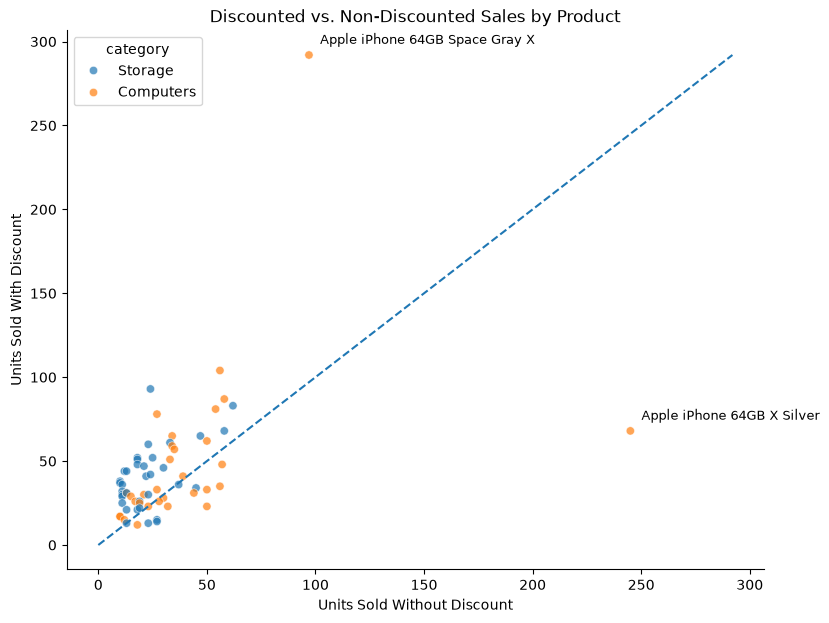

In [259]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

ax = sns.scatterplot(
    data=robust_product_comparison,
    x="No Discount",
    y="Discounted",
    hue="category",
    alpha=0.7
)

# Reference line
max_units = max(
    robust_product_comparison["No Discount"].max(),
    robust_product_comparison["Discounted"].max()
)

plt.plot(
    [0, max_units],
    [0, max_units],
    linestyle="--"
)

# Identify the two extreme products
products_to_label = robust_product_comparison.loc[
    [
        robust_product_comparison["Discounted"].idxmax(),
        robust_product_comparison["No Discount"].idxmax()
    ]
]


# Remove top and right borders
sns.despine()

# Add labels
for _, row in products_to_label.iterrows():
    ax.annotate(
        row["name"],
        (row["No Discount"], row["Discounted"]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9
    )

plt.xlabel("Units Sold Without Discount")
plt.ylabel("Units Sold With Discount")
plt.title("Discounted vs. Non-Discounted Sales by Product")

# Save plot
plt.savefig(
    "discounted_vs_non_discounted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4.5.&nbsp;  Bar Plot:

In [269]:
# Create the category summary: 
category_sales = (
    robust_product_comparison
    .groupby("category")[["Discounted", "No Discount"]]
    .sum()
    .reset_index()
)

category_sales

discount_status,category,Discounted,No Discount
0,Computers,1550,1294
1,Storage,1400,800


# Reshape it for Seaborn:

In [270]:
category_sales_long = category_sales.melt(
    id_vars="category",
    value_vars=["Discounted", "No Discount"],
    var_name="Discount Status",
    value_name="Units Sold"
)

category_sales_long

,category,Discount Status,Units Sold
0,Computers,Discounted,1550
1,Storage,Discounted,1400
2,Computers,No Discount,1294
3,Storage,No Discount,800


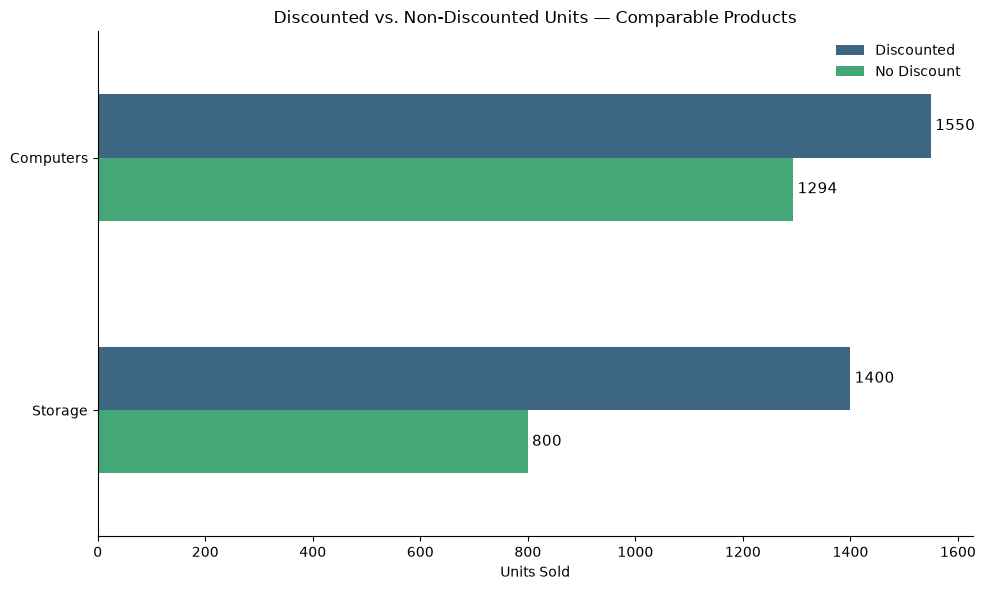

In [348]:
# Horizontal Bar Plot
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_sales_long,
    y="category",
    x="Units Sold",
    hue="Discount Status",
    palette="viridis",
    width=0.5  # smaller/thinner bars
)

# Add values to bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=11
    )

sns.despine()

plt.xlabel("Units Sold")
plt.ylabel("")

plt.title(
    "Discounted vs. Non-Discounted Units — Comparable Products"
)

# Legend inside upper-right corner
plt.legend(
    title="",
    loc="upper right",
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "category_discount_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

So roughly 3 times (+201%) as many units were sold in discounted Apple Iphone 64GB Space Gray X. For Apple Iphone 64GB X Silver, 72% less of sold items with a discount were registered.

For the gray Iphone, even if discounting genuinely increases volume, it doesn't necessarily increase revenue or profit.

For the silver Iphone, one possible interpretation is that this product may not need discounting to generate demand. IT represents a notable counterexample to the overall pattern: substantially more units were recorded under non-discounted conditions, suggesting that discounts were not associated with higher unit sales for this product.

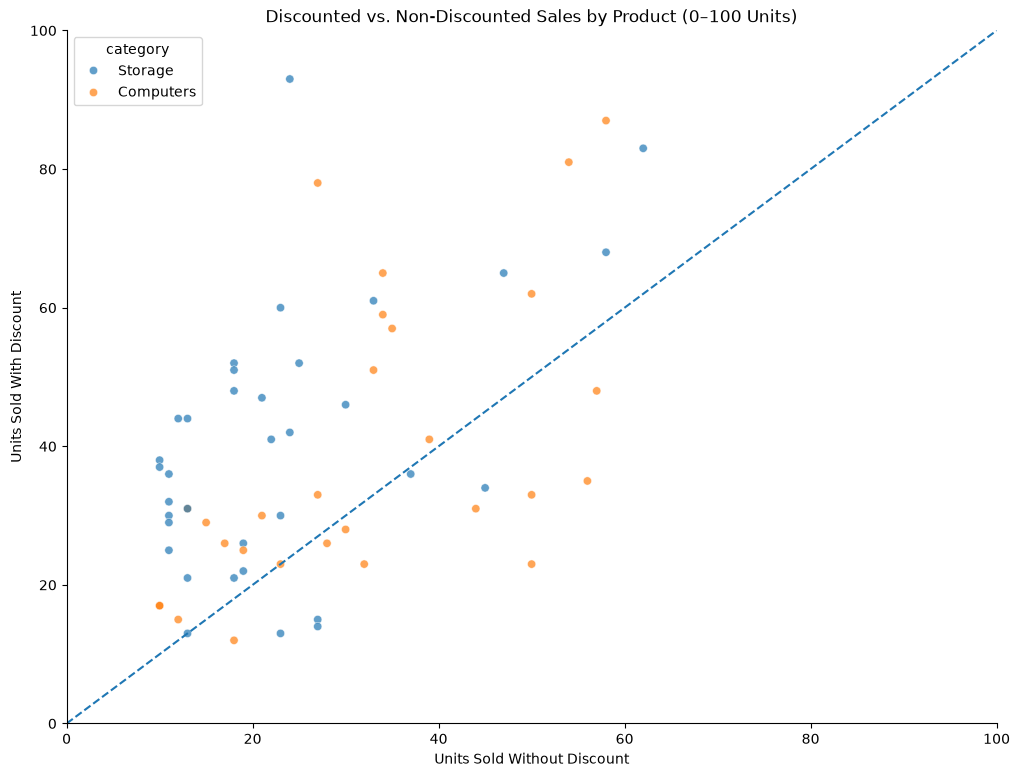

In [265]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))

ax = sns.scatterplot(
    data=robust_product_comparison,
    x="No Discount",
    y="Discounted",
    hue="category",
    alpha=0.7
)

# Equal-sales reference line
plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

# Zoom in
plt.xlim(0, 100)
plt.ylim(0, 100)

# Only label products visible in the close-up
products_visible = robust_product_comparison[
    (robust_product_comparison["No Discount"] <= 100) &
    (robust_product_comparison["Discounted"] <= 100)
]


# Remove top and right borders
sns.despine()

plt.xlabel("Units Sold Without Discount")
plt.ylabel("Units Sold With Discount")
plt.title(
    "Discounted vs. Non-Discounted Sales by Product (0–100 Units)"
)

# Save plot
plt.savefig(
    "discounted_vs_non_discounted_zoom.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [328]:
# Create shortened product names
top_products = top_products.copy()

top_products["short_name"] = (
    top_products["name"]
    .astype(str)
    .str[:20]
)

# Add "..." to names longer than 20 characters
top_products["short_name"] = top_products.apply(
    lambda row: row["short_name"] + "..."
    if len(str(row["name"])) > 20
    else row["short_name"],
    axis=1
)

In [324]:
top_products_long = top_products.melt(
    id_vars=["sku", "name", "short_name", "category", "subcategory"],
    value_vars=["Discounted", "No Discount"],
    var_name="Discount Status",
    value_name="Units Sold"
)

In [325]:
product_order = (
    top_products
    .sort_values(
        "units_difference_abs",
        ascending=False
    )["short_name"]
)

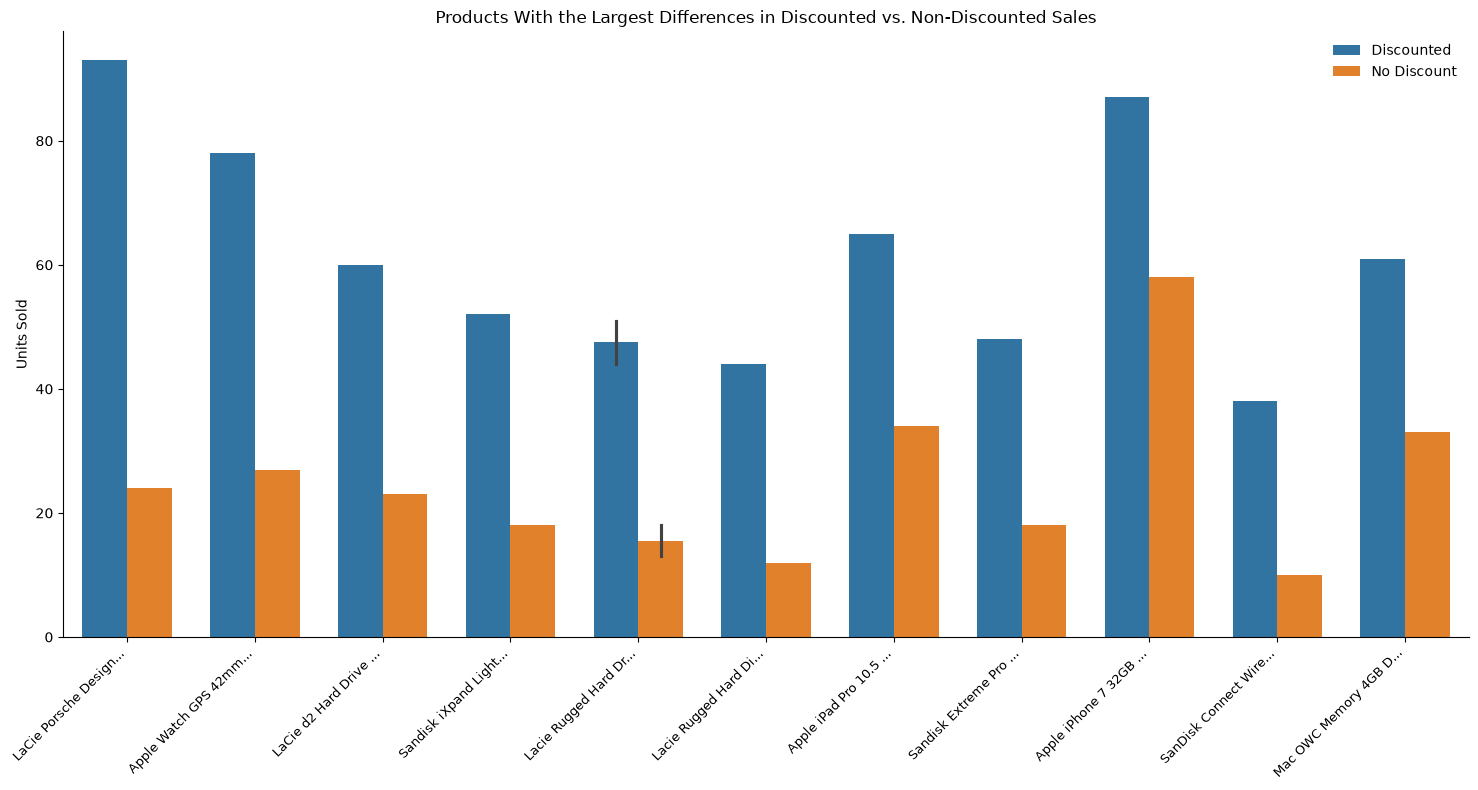

In [326]:
plt.figure(figsize=(15, 8))

ax = sns.barplot(
    data=top_products_long,
    x="short_name",
    y="Units Sold",
    hue="Discount Status",
    order=product_order,
    width=0.7
)

# Remove top and right borders
sns.despine()

plt.xlabel("")
plt.ylabel("Units Sold")

plt.title(
    "Products With the Largest Differences in Discounted vs. Non-Discounted Sales"
)

# Rotate names so they are readable
plt.xticks(
    rotation=45,
    ha="right",
    fontsize=9
)

plt.legend(
    title="",
    loc="upper right",
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "discounted_vs_non_discounted_zoom.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

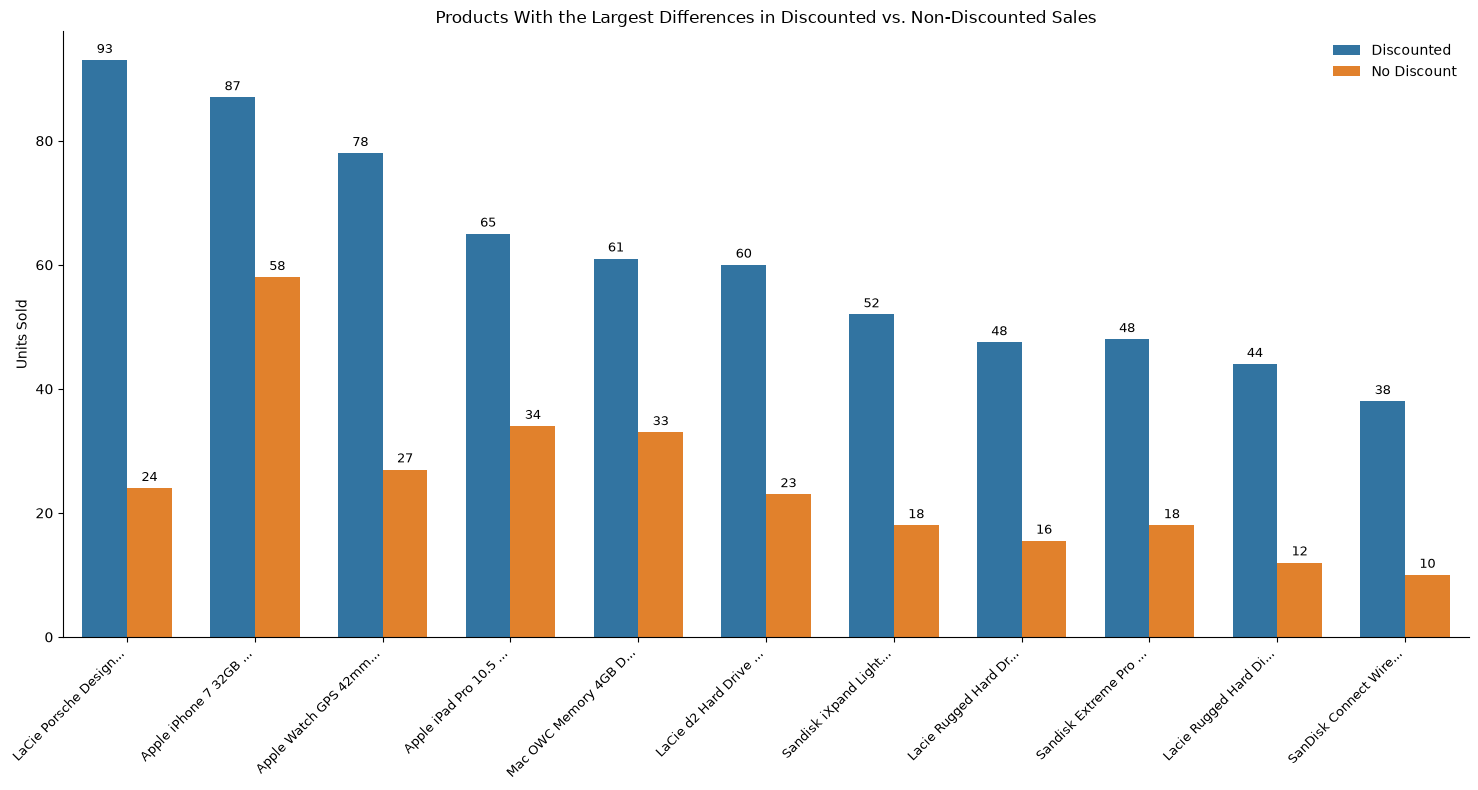

In [330]:
# Order products by discounted units, highest to lowest
product_order = (
    top_products
    .sort_values("Discounted", ascending=False)["short_name"]
    .tolist()
)

plt.figure(figsize=(15, 8))

ax = sns.barplot(
    data=top_products_long,
    x="short_name",
    y="Units Sold",
    hue="Discount Status",
    hue_order=["Discounted", "No Discount"],
    order=product_order,
    width=0.7,
    errorbar=None
)

# Add values above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

# Remove top and right borders
sns.despine()

plt.xlabel("")
plt.ylabel("Units Sold")

plt.title(
    "Products With the Largest Differences in Discounted vs. Non-Discounted Sales"
)

# Rotate product names
plt.xticks(
    rotation=45,
    ha="right",
    fontsize=9
)

plt.legend(
    title="",
    loc="upper right",
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "discounted_vs_non_discounted_zoom.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

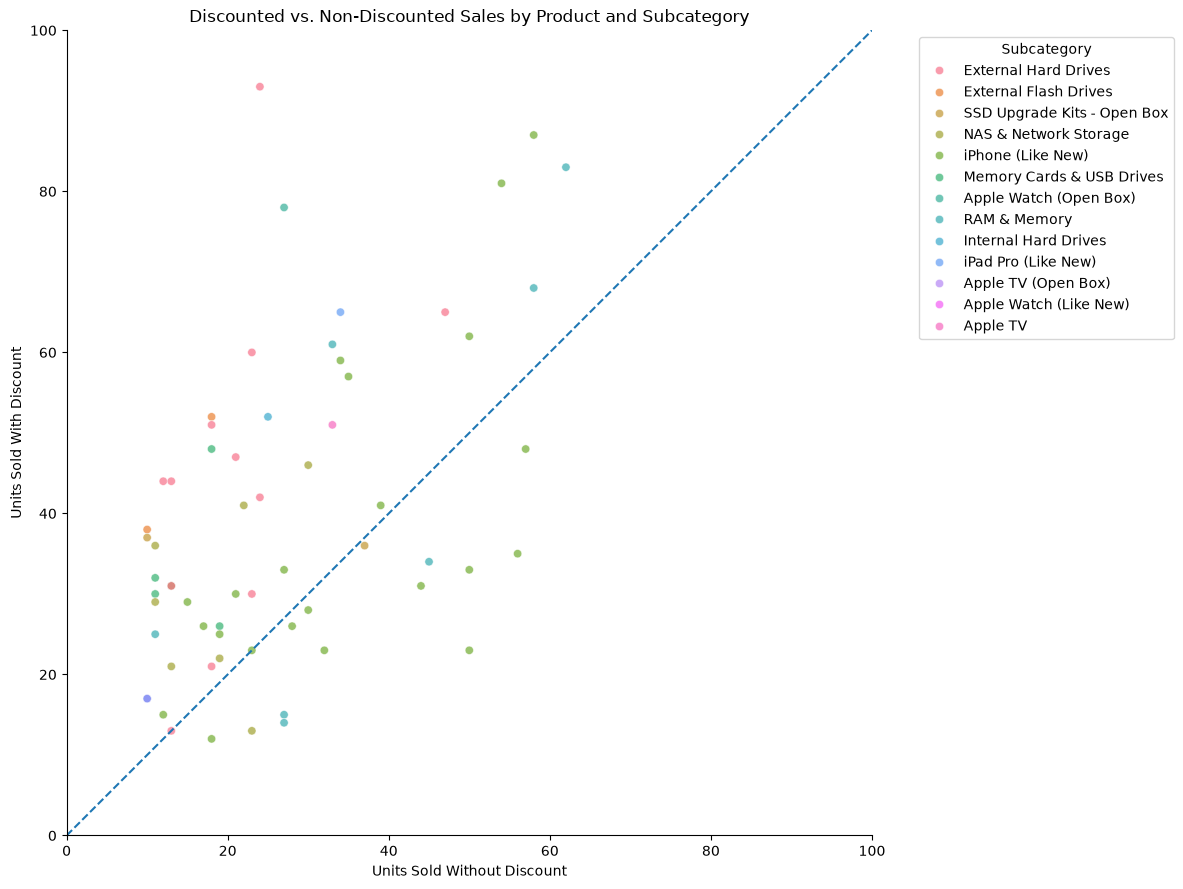

In [322]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))

ax = sns.scatterplot(
    data=robust_product_comparison,
    x="No Discount",
    y="Discounted",
    hue="subcategory",
    alpha=0.7
)

# Equal-sales reference line
plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

# Zoom in
plt.xlim(0, 100)
plt.ylim(0, 100)

# Remove top and right borders
sns.despine()

plt.xlabel("Units Sold Without Discount")
plt.ylabel("Units Sold With Discount")
plt.title(
    "Discounted vs. Non-Discounted Sales by Product and Subcategory"
)

# Move legend outside the plot
plt.legend(
    title="Subcategory",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [331]:
subcategory_sales = (
    robust_product_comparison
    .groupby("subcategory")[["Discounted", "No Discount"]]
    .sum()
    .reset_index()
)

subcategory_sales

discount_status,subcategory,Discounted,No Discount
0,Apple TV,51,33
1,Apple TV (Open Box),104,56
2,Apple Watch (Like New),17,10
3,Apple Watch (Open Box),78,27
4,External Flash Drives,90,28
5,External Hard Drives,541,249
6,Internal Hard Drives,52,25
7,Memory Cards & USB Drives,136,59
8,NAS & Network Storage,208,129
9,RAM & Memory,300,263


In [332]:
subcategory_sales_long = subcategory_sales.melt(
    id_vars="subcategory",
    value_vars=["Discounted", "No Discount"],
    var_name="Discount Status",
    value_name="Units Sold"
)

In [333]:
subcategory_order = (
    subcategory_sales
    .sort_values("Discounted", ascending=False)["subcategory"]
    .tolist()
)

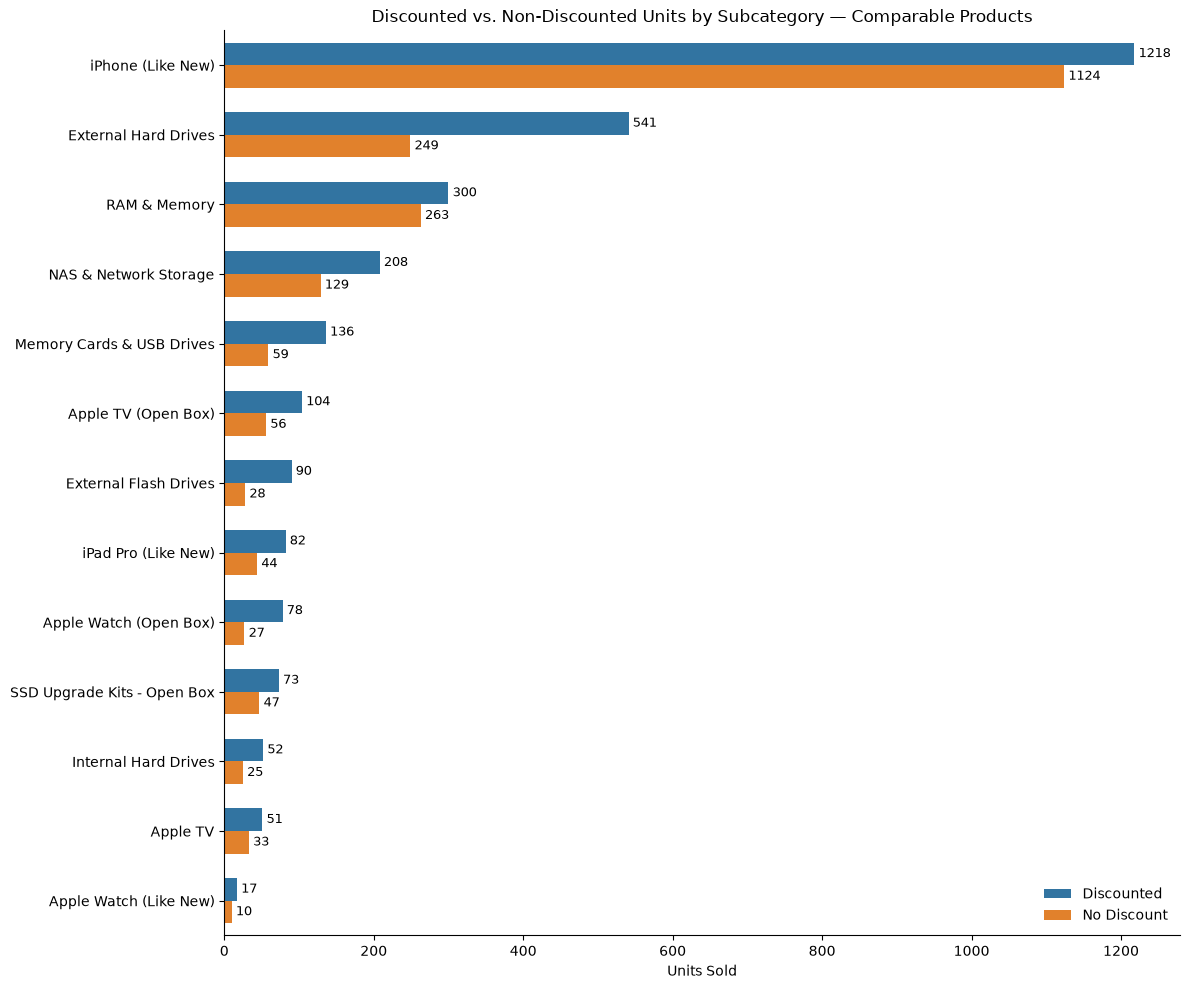

In [334]:
plt.figure(figsize=(12, 10))

ax = sns.barplot(
    data=subcategory_sales_long,
    y="subcategory",
    x="Units Sold",
    hue="Discount Status",
    hue_order=["Discounted", "No Discount"],
    order=subcategory_order,
    width=0.65,
    errorbar=None
)

# Add values to each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

sns.despine()

plt.xlabel("Units Sold")
plt.ylabel("")

plt.title(
    "Discounted vs. Non-Discounted Units by Subcategory — Comparable Products"
)

plt.legend(
    title="",
    loc="lower right",
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "subcategory_discount_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

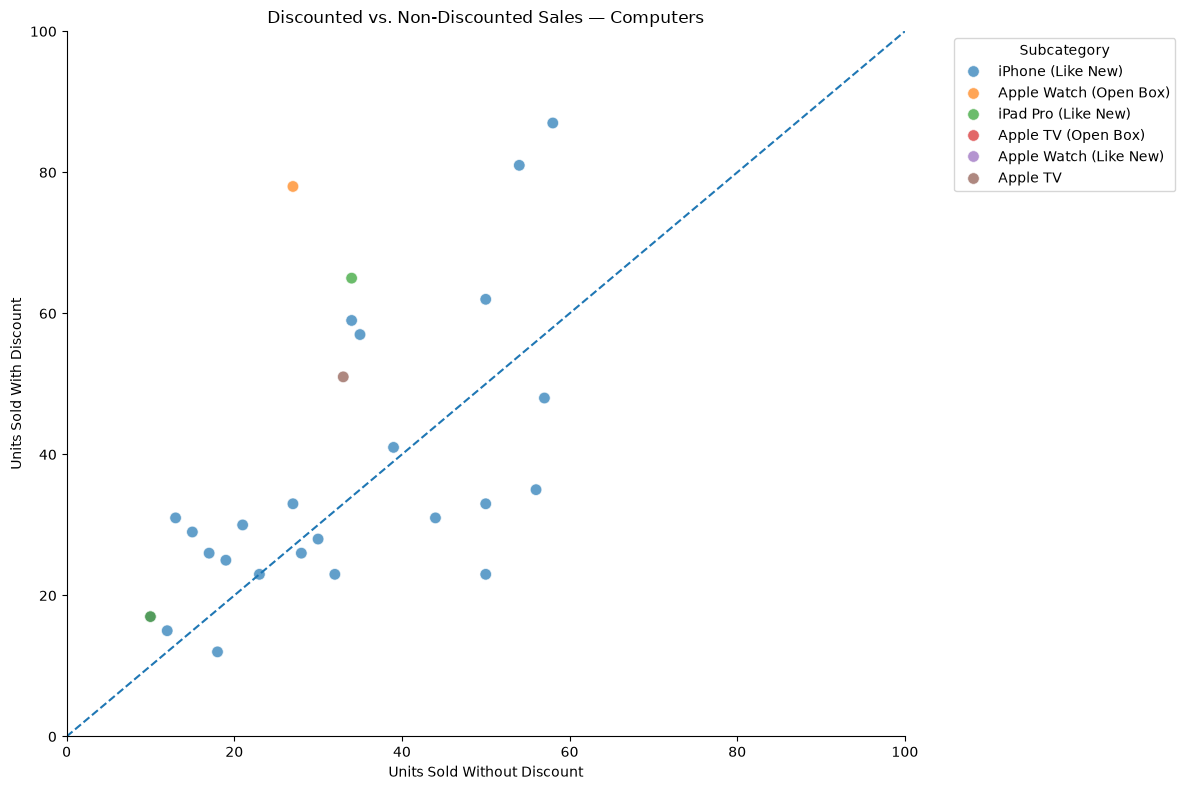

In [262]:
computers_plot = robust_product_comparison[
    robust_product_comparison["category"] == "Computers"
]

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=computers_plot,
    x="No Discount",
    y="Discounted",
    hue="subcategory",
    alpha=0.7,
    s=70
)

# Equal-sales reference line
plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlim(0, 100)
plt.ylim(0, 100)

sns.despine()

plt.xlabel("Units Sold Without Discount")
plt.ylabel("Units Sold With Discount")
plt.title("Discounted vs. Non-Discounted Sales — Computers")

plt.legend(
    title="Subcategory",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

# Save plot
plt.savefig(
    "discounted_vs_non_computers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [335]:
computers_subcategories = (
    robust_product_comparison[
        robust_product_comparison["category"] == "Computers"
    ]
    .groupby("subcategory")[["Discounted", "No Discount"]]
    .sum()
    .reset_index()
)

# Convert to long format
computers_long = computers_subcategories.melt(
    id_vars="subcategory",
    value_vars=["Discounted", "No Discount"],
    var_name="Discount Status",
    value_name="Units Sold"
)

# Order by discounted units
computers_order = (
    computers_subcategories
    .sort_values("Discounted", ascending=False)["subcategory"]
    .tolist()
)

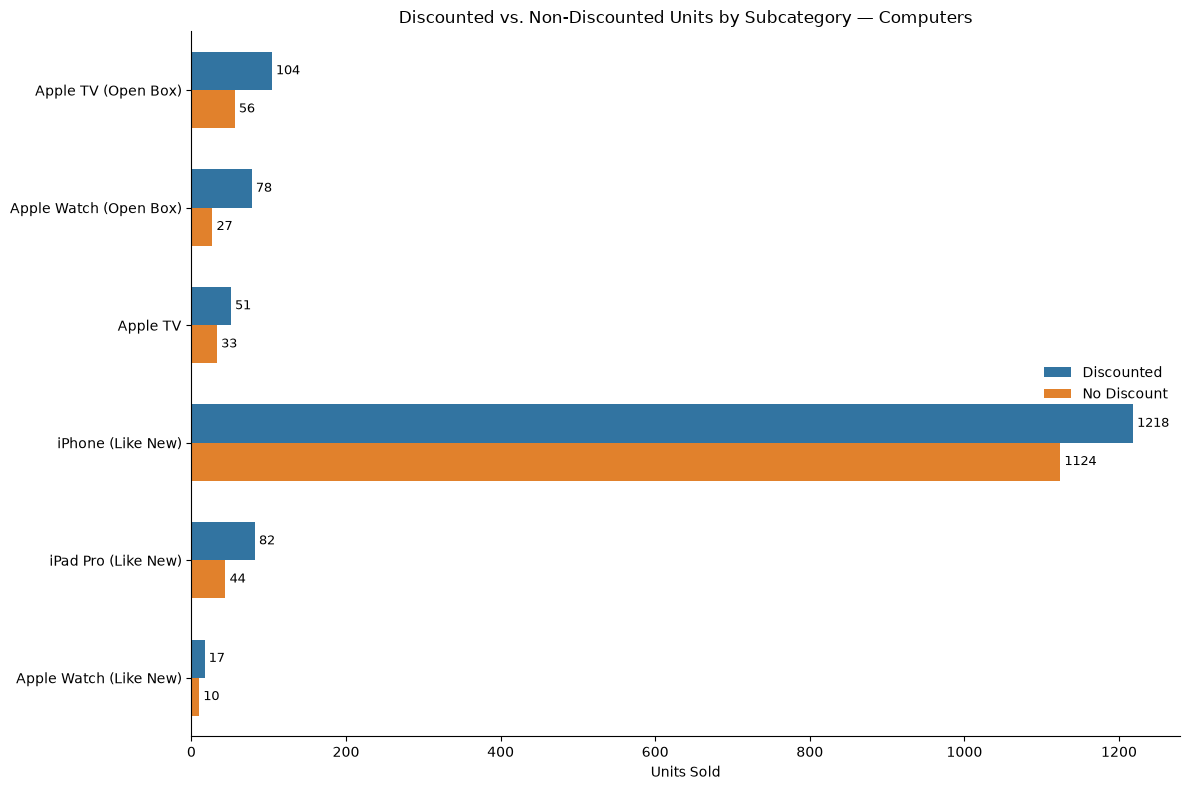

In [353]:
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=computers_long,
    y="subcategory",
    x="Units Sold",
    hue="Discount Status",
    hue_order=["Discounted", "No Discount"],
    order=computers_order,
    width=0.65,
    errorbar=None
)

# Add values to bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

sns.despine()

plt.xlabel("Units Sold")
plt.ylabel("")

plt.title(
    "Discounted vs. Non-Discounted Units by Subcategory — Computers"
)

plt.legend(
    title="",
    loc="center right",
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "subcategory_discount_computers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [352]:
storage_subcategories = (
    robust_product_comparison[
        robust_product_comparison["category"] == "Storage"
    ]
    .groupby("subcategory")[["Discounted", "No Discount"]]
    .sum()
    .reset_index()
)

storage_long = storage_subcategories.melt(
    id_vars="subcategory",
    value_vars=["Discounted", "No Discount"],
    var_name="Discount Status",
    value_name="Units Sold"
)

storage_order = (
    storage_subcategories
    .sort_values("Discounted", ascending=False)["subcategory"]
    .tolist()
)

In [354]:
# Calculate the values shown by barplot (mean is its default)
bar_values = (
    storage_long
    .groupby(["subcategory", "Discount Status"], observed=True)["Units Sold"]
    .mean()
    .unstack("Discount Status")
)

# Order subcategories by their largest bar, descending
storage_order = (
    bar_values
    .max(axis=1)
    .sort_values(ascending=False)
    .index
    .tolist()
)

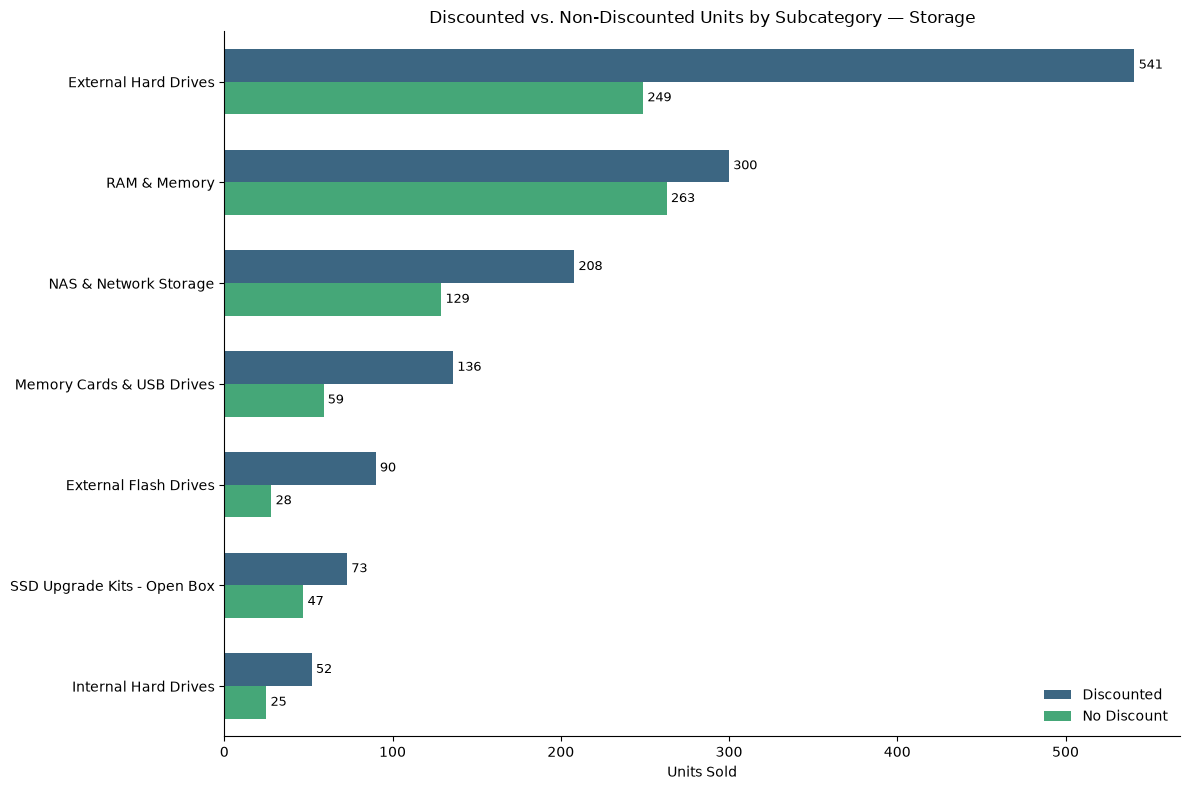

In [355]:
plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=storage_long,
    y="subcategory",
    x="Units Sold",
    hue="Discount Status",
    hue_order=["Discounted", "No Discount"],
    order=storage_order,
    palette="viridis",
    width=0.65,
    errorbar=None
)

# Add values to bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

sns.despine()

plt.xlabel("Units Sold")
plt.ylabel("")

plt.title(
    "Discounted vs. Non-Discounted Units by Subcategory — Storage"
)

plt.legend(
    title="",
    loc="lower right",
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "subcategory_discount_storage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [343]:
subcategory_per_product = (
    robust_product_comparison
    .groupby(["category", "subcategory"])
    .agg(
        number_products=("sku", "nunique"),
        discounted_units=("Discounted", "sum"),
        no_discount_units=("No Discount", "sum")
    )
    .reset_index()
)

In [344]:
subcategory_per_product["discounted_units_per_product"] = (
    subcategory_per_product["discounted_units"]
    / subcategory_per_product["number_products"]
)

subcategory_per_product["no_discount_units_per_product"] = (
    subcategory_per_product["no_discount_units"]
    / subcategory_per_product["number_products"]
)

subcategory_per_product

,category,subcategory,number_products,discounted_units,no_discount_units,discounted_units_per_product,no_discount_units_per_product
0,Computers,Apple TV,1,51,33,51.00,33.00
1,Computers,Apple TV (Open Box),1,104,56,104.00,56.00
2,Computers,Apple Watch (Like New),1,17,10,17.00,10.00
3,Computers,Apple Watch (Open Box),1,78,27,78.00,27.00
4,Computers,iPad Pro (Like New),2,82,44,41.00,22.00
5,Computers,iPhone (Like New),25,1218,1124,48.72,44.96
6,Storage,External Flash Drives,2,90,28,45.00,14.00
7,Storage,External Hard Drives,12,541,249,45.08,20.75
8,Storage,Internal Hard Drives,1,52,25,52.00,25.00
9,Storage,Memory Cards & USB Drives,4,136,59,34.00,14.75


In [345]:
subcategory_per_product_long = subcategory_per_product.melt(
    id_vars=["category", "subcategory", "number_products"],
    value_vars=[
        "discounted_units_per_product",
        "no_discount_units_per_product"
    ],
    var_name="Discount Status",
    value_name="Units per Product"
)

subcategory_per_product_long["Discount Status"] = (
    subcategory_per_product_long["Discount Status"]
    .replace({
        "discounted_units_per_product": "Discounted",
        "no_discount_units_per_product": "No Discount"
    })
)

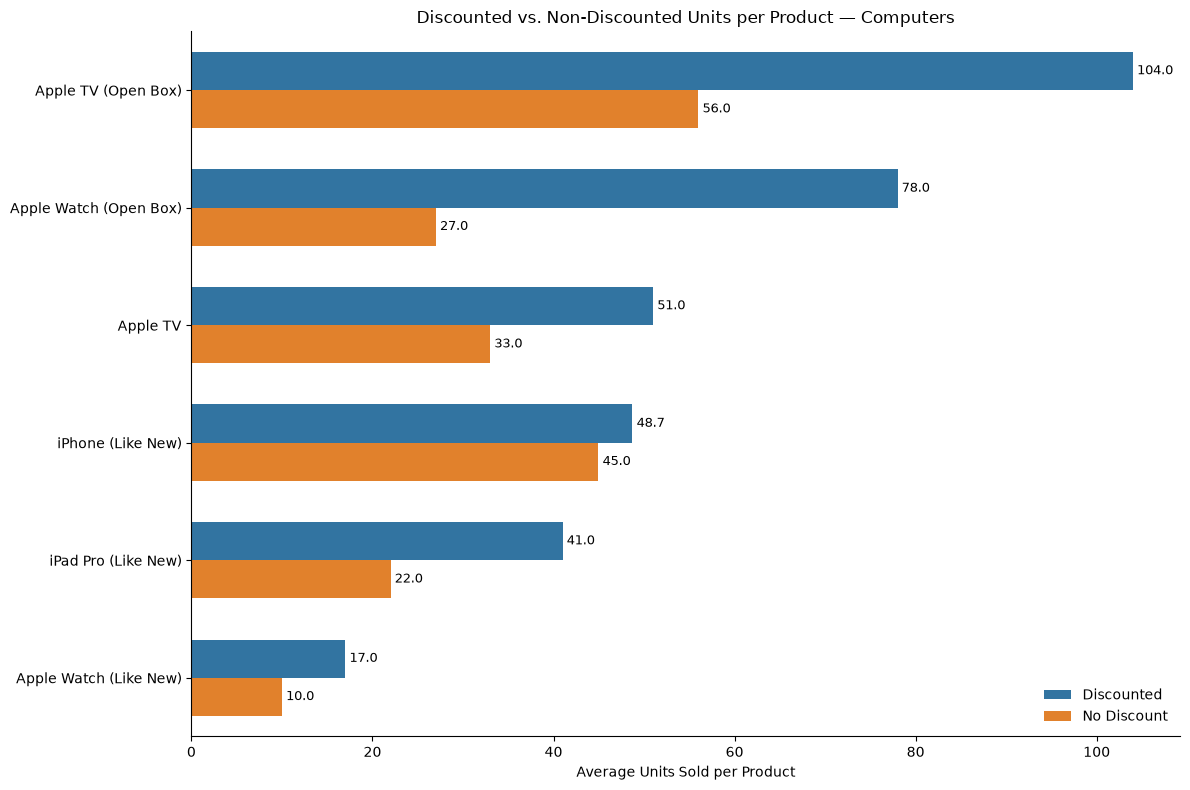

In [346]:
computers_per_product = subcategory_per_product_long[
    subcategory_per_product_long["category"] == "Computers"
]

# Order by discounted units per product
computers_order = (
    subcategory_per_product[
        subcategory_per_product["category"] == "Computers"
    ]
    .sort_values(
        "discounted_units_per_product",
        ascending=False
    )["subcategory"]
    .tolist()
)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=computers_per_product,
    y="subcategory",
    x="Units per Product",
    hue="Discount Status",
    hue_order=["Discounted", "No Discount"],
    order=computers_order,
    width=0.65,
    errorbar=None
)

# Values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3,
        fontsize=9
    )

sns.despine()

plt.xlabel("Average Units Sold per Product")
plt.ylabel("")

plt.title(
    "Discounted vs. Non-Discounted Units per Product — Computers"
)

plt.legend(
    title="",
    loc="lower right",
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "subcategory_per_product_computers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

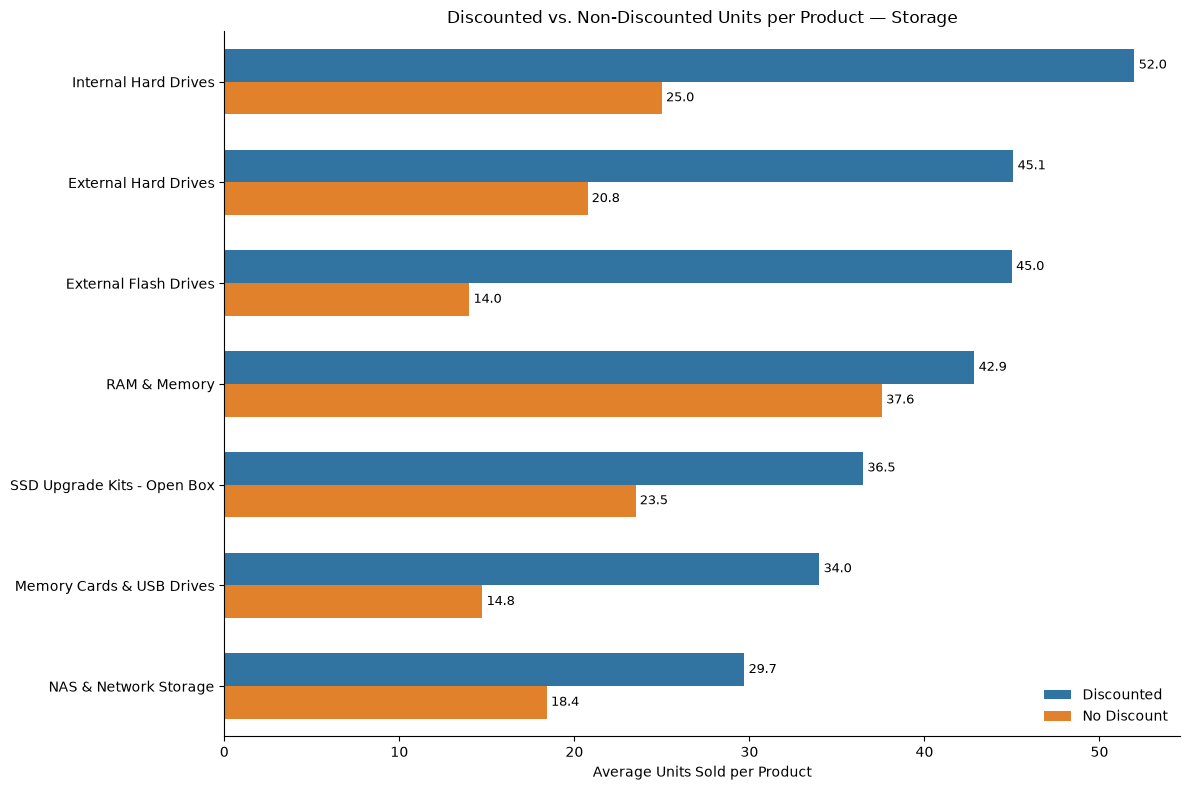

In [347]:
storage_per_product = subcategory_per_product_long[
    subcategory_per_product_long["category"] == "Storage"
]

storage_order = (
    subcategory_per_product[
        subcategory_per_product["category"] == "Storage"
    ]
    .sort_values(
        "discounted_units_per_product",
        ascending=False
    )["subcategory"]
    .tolist()
)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=storage_per_product,
    y="subcategory",
    x="Units per Product",
    hue="Discount Status",
    hue_order=["Discounted", "No Discount"],
    order=storage_order,
    width=0.65,
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3,
        fontsize=9
    )

sns.despine()

plt.xlabel("Average Units Sold per Product")
plt.ylabel("")

plt.title(
    "Discounted vs. Non-Discounted Units per Product — Storage"
)

plt.legend(
    title="",
    loc="lower right",
    frameon=False
)

plt.tight_layout()

plt.savefig(
    "subcategory_per_product_storage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

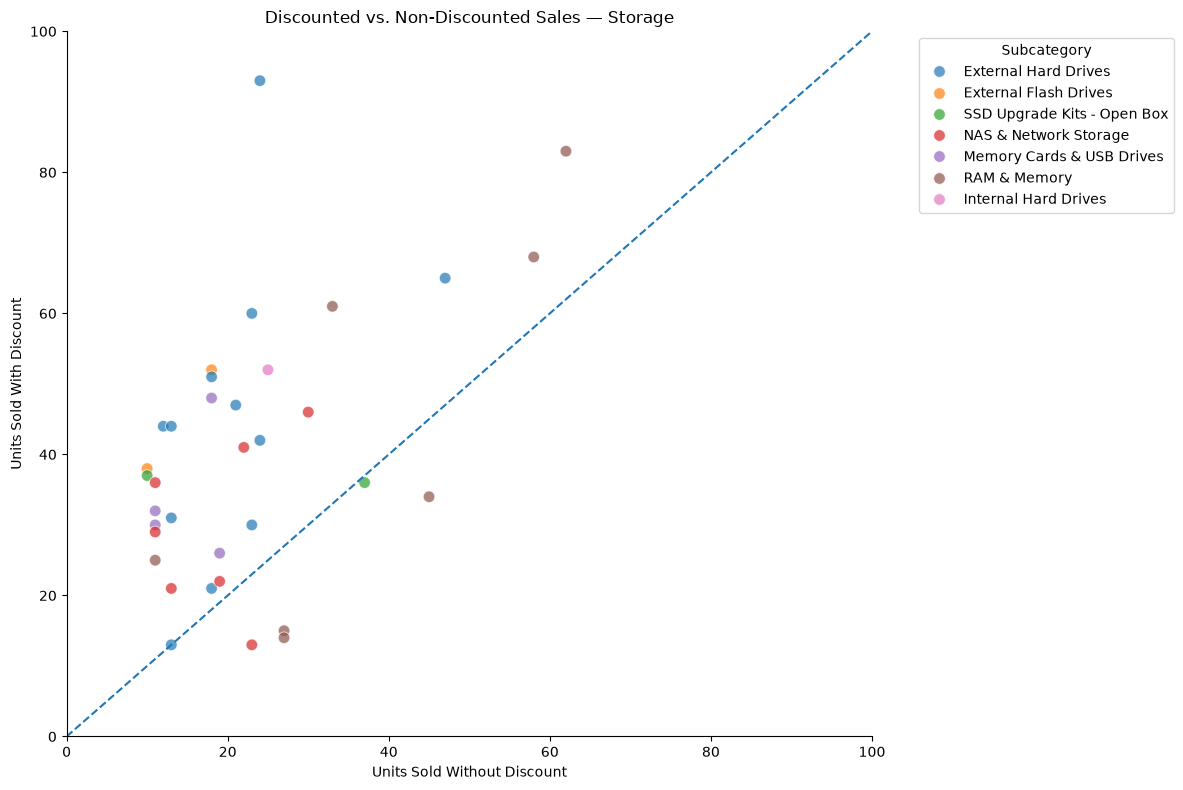

In [261]:
storage_plot = robust_product_comparison[
    robust_product_comparison["category"] == "Storage"
]

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=storage_plot,
    x="No Discount",
    y="Discounted",
    hue="subcategory",
    alpha=0.7,
    s=70
)

# Equal-sales reference line
plt.plot(
    [0, 100],
    [0, 100],
    linestyle="--"
)

plt.xlim(0, 100)
plt.ylim(0, 100)

sns.despine()

plt.xlabel("Units Sold Without Discount")
plt.ylabel("Units Sold With Discount")
plt.title("Discounted vs. Non-Discounted Sales — Storage")

plt.legend(
    title="Subcategory",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

# Save plot
plt.savefig(
    "discounted_vs_non_discounted_storage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 5.&nbsp;  Let's explore the discount with the **margins**

In [241]:
# Include the margins directly
margins = {
    "Computers": 0.10,
    "Displays": 0.15,
    "Storage": 0.20
}

discount_clean["margin"] = (
    discount_clean["category"]
    .map(margins)
    .fillna(0.50)
)

In [242]:
discount_clean[
    ["category", "margin"]
].drop_duplicates()

,category,margin
0,Storage,0.20
1,Accessories,0.50
2,Power,0.50
3,Computers,0.10
5,Audio,0.50
9,Peripherals,0.50
12,Displays,0.15
18,Networking,0.50
34,Software & Services,0.50
47,Smart Home,0.50


In [244]:
# Include the estimated costs ('manufacturing costs')
discount_clean["estimated_cost"] = (
    discount_clean["price"]
    * (1 - discount_clean["margin"])
)

In [245]:
# Calculate profit per unit
discount_clean["profit_per_unit"] = (
    discount_clean["unit_price"]
    - discount_clean["estimated_cost"]
)

Notice something important: with the 10% margin assumption for Computers, discounts greater than 10% imply an estimated negative gross profit. **That's potentially a very important result for your project.**

In [246]:
# Calculate profit for the entire order line:
discount_clean["line_profit"] = (
    discount_clean["product_quantity"]
    * discount_clean["profit_per_unit"]
)

In [263]:
discount_clean[
    [
        "sku",
        "name",
        "category",
        "price",
        "margin",
        "estimated_cost",
        "unit_price",
        "product_quantity",
        "unit_price_total",
        "profit_per_unit",
        "line_profit"
    ]
].head(30)

,sku,name,category,price,margin,estimated_cost,unit_price,product_quantity,unit_price_total,profit_per_unit,line_profit
0,OWC0100,OWC In-line Digital Temperature Sensor Kit HDD...,Storage,60.99,0.20,48.79,47.49,1,47.49,-1.30,-1.30
1,IOT0014,iOttie Easy View 2 Car Black Support,Accessories,22.95,0.50,11.47,18.99,1,18.99,7.51,7.51
2,APP0700,Apple 85W MagSafe 2 charger MacBook Pro screen...,Power,89.00,0.50,44.50,72.19,1,72.19,27.69,27.69
3,PAC0929,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",Computers,3209.00,0.10,2888.10,2565.99,1,2565.99,-322.11,-322.11
4,APP1854,"Apple MacBook Pro 13 ""with Touch Bar 33GHz Cor...",Computers,3279.00,0.10,2951.10,3278.99,1,3278.99,327.89,327.89
5,BEA0065,Solo3 Beats Headphones Wireless On-Ear Rose Gold,Audio,299.95,0.50,149.97,256.49,1,256.49,106.52,106.52
6,CRU0039-A,(Open) Crucial 240GB SSD 7mm BX200,Accessories,76.99,0.50,38.49,60.90,1,60.90,22.41,22.41
7,PEB0015,Pebble Smartwatch Time Steel Black,Audio,299.99,0.50,150.00,142.49,1,142.49,-7.50,-7.50
8,BEA0065,Solo3 Beats Headphones Wireless On-Ear Rose Gold,Audio,299.95,0.50,149.97,256.49,1,256.49,106.52,106.52
9,SAT0010,Satechi Aluminum Silver Mouse,Peripherals,29.99,0.50,14.99,18.99,1,18.99,3.99,3.99


In [248]:
# Add realized margin
discount_clean["realized_margin_pct"] = (
    discount_clean["profit_per_unit"]
    / discount_clean["unit_price"]
    * 100
)

In [249]:
discount_clean[
    [
        "sku",
        "category",
        "price",
        "unit_price",
        "discount_pct",
        "margin",
        "estimated_cost",
        "profit_per_unit",
        "line_profit",
        "realized_margin_pct"
    ]
].head(10)

,sku,category,price,unit_price,discount_pct,margin,estimated_cost,profit_per_unit,line_profit,realized_margin_pct
0,OWC0100,Storage,60.99,47.49,22.13,0.20,48.79,-1.30,-1.30,-2.74
1,IOT0014,Accessories,22.95,18.99,17.25,0.50,11.47,7.51,7.51,39.57
2,APP0700,Power,89.00,72.19,18.89,0.50,44.50,27.69,27.69,38.36
3,PAC0929,Computers,3209.00,2565.99,20.04,0.10,2888.10,-322.11,-322.11,-12.55
4,APP1854,Computers,3279.00,3278.99,0.00,0.10,2951.10,327.89,327.89,10.00
5,BEA0065,Audio,299.95,256.49,14.49,0.50,149.97,106.52,106.52,41.53
6,CRU0039-A,Accessories,76.99,60.90,20.90,0.50,38.49,22.41,22.41,36.79
7,PEB0015,Audio,299.99,142.49,52.50,0.50,150.00,-7.50,-7.50,-5.27
8,BEA0065,Audio,299.95,256.49,14.49,0.50,149.97,106.52,106.52,41.53
9,SAT0010,Peripherals,29.99,18.99,36.68,0.50,14.99,3.99,3.99,21.04


In [250]:
discounted_sales = discount_clean[
    discount_clean["discount_pct"] > 0
].copy()

In [251]:
loss_sales = discounted_sales[
    discounted_sales["profit_per_unit"] < 0
].copy()

print("Discounted order lines:", len(discounted_sales))
print("Order lines sold at estimated loss:", len(loss_sales))
print(
    "Percentage sold at estimated loss:",
    len(loss_sales) / len(discounted_sales) * 100
)

Discounted order lines: 104669
Order lines sold at estimated loss: 24927
Percentage sold at estimated loss: 23.815074186244257


In [252]:
loss_by_category = (
    discounted_sales
    .groupby("category")
    .agg(
        discounted_orderlines=("sku", "size"),
        loss_orderlines=(
            "profit_per_unit",
            lambda x: (x < 0).sum()
        )
    )
)

loss_by_category["loss_pct"] = (
    loss_by_category["loss_orderlines"]
    / loss_by_category["discounted_orderlines"]
    * 100
)

loss_by_category

,discounted_orderlines,loss_orderlines,loss_pct
category,,,
Accessories,20114,3442,17.11
Audio,10576,1384,13.09
Computers,17282,5448,31.52
Displays,2605,1144,43.92
Networking,883,49,5.55
Peripherals,15337,1883,12.28
Power,6340,751,11.85
Smart Home,363,93,25.62
Software & Services,3484,340,9.76


**This tell us you the proportion of discounted order lines estimated to have negative gross profit (and quite a considerable one)**

In [253]:
# Calculate units osold at an estimated loss
discounted_sales["sold_at_loss"] = (
    discounted_sales["profit_per_unit"] < 0
)

loss_units_by_category = (
    discounted_sales
    .groupby("category")
    .apply(
        lambda x: pd.Series({
            "discounted_units": x["product_quantity"].sum(),
            "units_sold_at_loss": x.loc[
                x["sold_at_loss"],
                "product_quantity"
            ].sum()
        }),
        include_groups=False
    )
)

loss_units_by_category["loss_units_pct"] = (
    loss_units_by_category["units_sold_at_loss"]
    / loss_units_by_category["discounted_units"]
    * 100
)

loss_units_by_category

,discounted_units,units_sold_at_loss,loss_units_pct
category,,,
Accessories,21163,3644,17.22
Audio,12245,1660,13.56
Computers,17708,5565,31.43
Displays,2967,1335,44.99
Networking,969,54,5.57
Peripherals,17276,2543,14.72
Power,6844,836,12.22
Smart Home,407,99,24.32
Software & Services,3681,343,9.32


In [254]:
profit_by_category = (
    discounted_sales
    .groupby("category")
    .agg(
        units_sold=("product_quantity", "sum"),
        sales_value=("unit_price_total", "sum"),
        estimated_profit=("line_profit", "sum"),
        avg_discount=("discount_pct", "mean"),
        avg_realized_margin=("realized_margin_pct", "mean")
    )
)

profit_by_category

,units_sold,sales_value,estimated_profit,avg_discount,avg_realized_margin
category,,,,,
Accessories,21163,801657.09,231938.54,29.90,16.05
Audio,12245,1212203.06,364044.98,24.74,20.50
Computers,17708,23101459.25,67460.99,9.07,-0.54
Displays,2967,1213881.80,31773.92,13.21,1.31
Networking,969,62522.89,19703.80,27.23,25.98
Peripherals,17276,1682107.82,637890.78,24.86,27.17
Power,6844,373436.31,130326.58,23.92,19.87
Smart Home,407,57330.57,13059.46,33.31,6.73
Software & Services,3681,308608.70,47391.39,27.15,-107.29


In [257]:
margin_analysis = discounted_sales[
    discounted_sales["category"].isin(
        ["Computers", "Storage"]
    )
].copy()

margin_analysis["realized_margin_pct"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

count   44967.00
mean       -3.00
std        52.18
min     -2059.20
1%        -76.68
5%        -31.61
25%        -4.12
50%         3.82
75%         8.23
95%        16.97
99%        19.54
max        20.00
Name: realized_margin_pct, dtype: float64

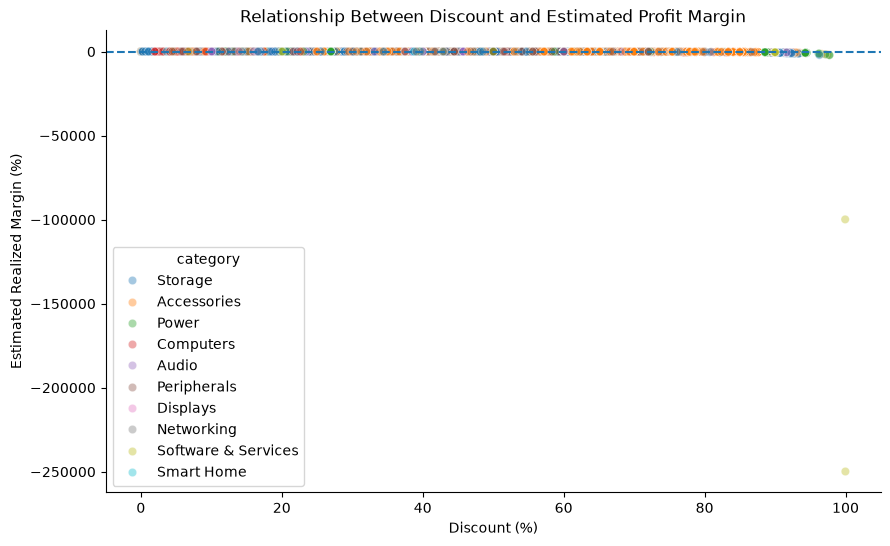

In [255]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=discounted_sales,
    x="discount_pct",
    y="realized_margin_pct",
    hue="category",
    alpha=0.4
)

plt.axhline(0, linestyle="--")

sns.despine()

plt.xlabel("Discount (%)")
plt.ylabel("Estimated Realized Margin (%)")
plt.title("Relationship Between Discount and Estimated Profit Margin")

plt.show()

### 5.&nbsp;  Let's explore the discount behavior

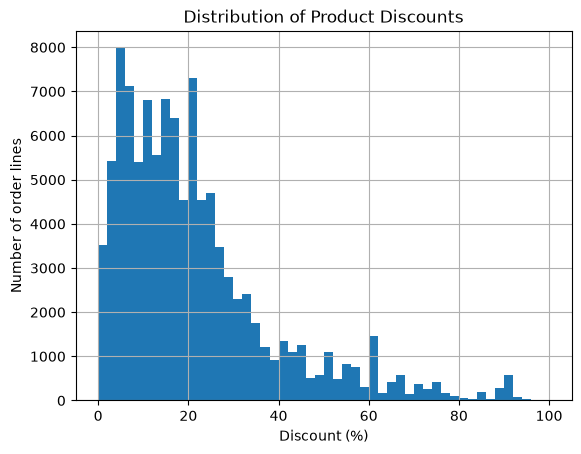

In [100]:
import matplotlib.pyplot as plt

discounted_sales["discount_pct"].hist(
    bins=50,
    range=(0, 100)
)

plt.xlabel("Discount (%)")
plt.ylabel("Number of order lines")
plt.title("Distribution of Product Discounts")
plt.show()

In [101]:
product_discounts = (
    discounted_sales
    .groupby(["sku", "name"])
    .agg(
        avg_discount_pct=("discount_pct", "mean"),
        median_discount_pct=("discount_pct", "median"),
        min_discount_pct=("discount_pct", "min"),
        max_discount_pct=("discount_pct", "max"),
        units_sold=("product_quantity", "sum"),
        transactions=("sku", "size")
    )
    .reset_index()
)

In [102]:
product_discounts.sort_values(
    "avg_discount_pct",
    ascending=False
).head(20)

,sku,name,avg_discount_pct,median_discount_pct,min_discount_pct,max_discount_pct,units_sold,transactions
5512,SEV0018,IMac RAM installation service,99.95,99.95,99.95,99.95,1,1
1534,BEL0145-A,Open - Belkin Switch + Motion WeMO Wi-Fi contr...,97.45,97.45,97.45,97.45,1,1
5031,PIE0034-A,Open - Piece Internal Battery iPhone 6,96.63,96.63,96.63,96.63,1,1
3625,MUV0158-A,"Open - Muvit Armband Universal Fino 47-57 ""Bla...",94.22,94.22,94.22,94.22,1,1
2922,KIN0153-A,(Open) Kingston SO-DIMM memory 8GB 1600Mhz DDR3åÊ,93.14,93.14,93.14,93.14,1,1
5094,PUR0144-A,"Open - Pure Nude Ultraslim 03 ""7 Clear iPhone ...",92.93,92.93,92.93,92.93,1,1
1951,DLK0068-A,Open - D-Link GO-SW-5E 5 port Fast Ethernet Sw...,92.93,92.93,92.93,92.93,1,1
2625,IHE0017-A,Open - iHealth Align Intelligent Mini glucímetro,92.91,92.91,92.91,92.91,1,1
3661,MYK0016-A,Open - MyKronoz ZeCircle Black Clock,92.69,92.69,92.69,92.69,1,1
3363,MAK0020-A,Open - Maclocks Security Bundle Case iPad Air ...,92.52,92.52,92.52,92.52,2,1


One warning here: average discount can be misleading. A product sold once at 80% off shouldn't necessarily rank above one sold 2,000 times at 25% off. Always consider units_sold or transactions alongside the discount.

In [103]:
discounted_sales["list_price_total"] = (
    discounted_sales["price"] *
    discounted_sales["product_quantity"]
)

In [104]:
total_list_value = discounted_sales["list_price_total"].sum()
total_actual_value = discounted_sales["unit_price_total"].sum()

overall_discount_pct = (
    (total_list_value - total_actual_value)
    / total_list_value
    * 100
)

print(f"Overall discount: {overall_discount_pct:.2f}%")

Overall discount: 13.65%


### 6.&nbsp;  Let's compare with orders:

In [105]:
order_check = (
    discounted_sales
    .groupby("id_order")
    .agg(
        product_revenue=("unit_price_total", "sum"),
        list_value=("list_price_total", "sum")
    )
    .reset_index()
)

In [106]:
order_check = order_check.merge(
    orders_df[["order_id", "total_paid"]],
    left_on="id_order",
    right_on="order_id",
    how="left"
)

In [107]:
order_check[
    ["product_revenue", "total_paid"]
].describe()

,product_revenue,total_paid
count,82697.00,82697.00
mean,414.78,427.15
std,766.68,780.18
min,2.31,0.00
25%,46.99,51.00
50%,117.99,126.98
75%,387.58,396.89
max,17910.34,20616.44


### 7.&nbsp;  Discount percentage categories:

In [108]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

labels = [
    "0-10%",
    "10-20%",
    "20-30%",
    "30-40%",
    "40-50%",
    "50-60%",
    "60-70%",
    "70-80%",
    "80-90%",
    "90-100%"
]

discounted_sales["discount_category"] = pd.cut(
    discounted_sales["discount_pct"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [109]:
discounted_sales["discount_category"].value_counts().sort_index()

discount_category
0-10%      29459
10-20%     30790
20-30%     22139
30-40%      8593
40-50%      4819
50-60%      3463
60-70%      2783
70-80%      1338
80-90%       597
90-100%      688
Name: count, dtype: int64

In [110]:
discount_summary = (
    discounted_sales["discount_category"]
    .value_counts()
    .sort_index()
    .to_frame("sales_count")
)

discount_summary["percentage"] = (
    discount_summary["sales_count"]
    / discount_summary["sales_count"].sum()
    * 100
)

discount_summary

,sales_count,percentage
discount_category,,
0-10%,29459,28.14
10-20%,30790,29.42
20-30%,22139,21.15
30-40%,8593,8.21
40-50%,4819,4.60
50-60%,3463,3.31
60-70%,2783,2.66
70-80%,1338,1.28
80-90%,597,0.57


This answers: **"How frequently was each level of discount offered?"**

There's an important difference. A particular SKU might have been sold 500 times with a 10–20% discount, so value_counts() would count 500 transactions.

If we instead want to know:
"How many different products were offered with each level of discount?"

use nunique():

In [111]:
products_by_discount = (
    discounted_sales
    .groupby("discount_category", observed=False)["sku"]
    .nunique()
)

products_by_discount

discount_category
0-10%      2538
10-20%     3192
20-30%     2701
30-40%     1531
40-50%      739
50-60%      391
60-70%      212
70-80%      116
80-90%       51
90-100%      76
Name: sku, dtype: int64

I'd actually look at both. The first tells you which discounts customers encountered most frequently, while the second tells you how broadly each discount level was applied across your product catalogue.
One caveat: a single SKU can appear in multiple discount categories if it was sold at different prices. So the unique-product counts across categories won't necessarily add up to the total number of unique products. That's useful information rather than an error—it tells you that discounting varies over time for the same product.

### 8.&nbsp;  Discount relation with sold products:

A scatter plot with a regression line is a good starting point. But first we need to decide what one point represents. For this question, I recommend one point = one product (SKU), with:
- X-axis: average discount % for that product
- Y-axis: number of units sold for that product
My current discounted_sales probably has multiple rows for the same SKU because the product was sold in multiple orders. So first let's create a product-level dataframe:

In [112]:
discount_sales_analysis = (
    discounted_sales
    .groupby(["sku", "name"])
    .agg(
        avg_discount_pct=("discount_pct", "mean"),
        units_sold=("product_quantity", "sum")
    )
    .reset_index()
)

discount_sales_analysis.head()

,sku,name,avg_discount_pct,units_sold
0,8MO0001-A,Open - Micro SD Adapter 8Mobility iSlice Macbo...,62.97,1
1,8MO0003-A,Open - 8Mobility iSlice Micro SD adapter for M...,63.29,1
2,8MO0007,8Mobility iSlice Micro SD adapter for Macbook ...,37.81,9
3,8MO0008,8Mobility iSlice Micro SD Adapter Macbook Pro ...,38.49,14
4,8MO0009,8Mobility iSlice Micro SD Adapter for Macbook ...,46.24,9


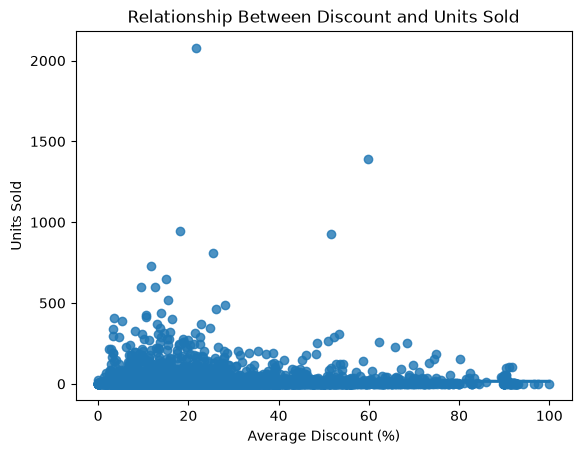

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=discount_sales_analysis,
    x="avg_discount_pct",
    y="units_sold"
)

plt.xlabel("Average Discount (%)")
plt.ylabel("Units Sold")
plt.title("Relationship Between Discount and Units Sold")

plt.show()

Overall, there doesn´t seem to be a relation between a larger discount and more items sold. However, this could change on a category analysis. 

### 8.&nbsp;  Discount vs categories analysis:

Which categories sell the most, which receive the largest discounts, and is a higher discount associated with higher sales within each category? First, let's add categories to our disscount tables.

In [114]:
discount_clean = discount_clean.merge(
    products_df[["sku", "category", "subcategory"]],
    on="sku",
    how="left"
)

Let's create category level summary:

In [120]:
category_analysis = (
    discount_clean
    .groupby("category")
    .agg(
        units_sold=("product_quantity", "sum"),
        avg_discount=("discount_pct", "mean"),
        median_discount=("discount_pct", "median"),
        number_products=("sku", "nunique"),
        sales_value=("unit_price_total", "sum")
    )
    .reset_index()
)

category_analysis

,category,units_sold,avg_discount,median_discount,number_products,sales_value
0,Accessories,23324,25.90,23.11,2338,895149.08
1,Audio,13075,23.12,16.67,574,1302852.64
2,Computers,20051,7.27,5.42,1165,25016686.61
3,Displays,3374,10.88,11.37,144,1400620.29
4,Networking,1116,23.06,24.25,95,84532.46
5,Peripherals,19100,22.49,18.75,653,1825582.82
6,Power,7361,22.16,19.31,274,408228.09
7,Smart Home,449,29.34,28.61,33,68579.24
8,Software & Services,4141,23.00,20.08,106,350509.22
9,Storage,35949,16.90,15.78,1504,5900093.77


In [122]:
category_analysis["units_per_product"] = (
    category_analysis["units_sold"]
    / category_analysis["number_products"]
)

category_analysis

,category,units_sold,avg_discount,median_discount,number_products,sales_value,units_per_product
0,Accessories,23324,25.90,23.11,2338,895149.08,9.98
1,Audio,13075,23.12,16.67,574,1302852.64,22.78
2,Computers,20051,7.27,5.42,1165,25016686.61,17.21
3,Displays,3374,10.88,11.37,144,1400620.29,23.43
4,Networking,1116,23.06,24.25,95,84532.46,11.75
5,Peripherals,19100,22.49,18.75,653,1825582.82,29.25
6,Power,7361,22.16,19.31,274,408228.09,26.86
7,Smart Home,449,29.34,28.61,33,68579.24,13.61
8,Software & Services,4141,23.00,20.08,106,350509.22,39.07
9,Storage,35949,16.90,15.78,1504,5900093.77,23.90


In [128]:
# Adding Percentages:
category_analysis["sales_value_pct"] = (
    category_analysis["sales_value"]
    / category_analysis["sales_value"].sum()
    * 100
)

category_analysis["units_sold_pct"] = (
    category_analysis["units_sold"]
    / category_analysis["units_sold"].sum()
    * 100
)
category_analysis

,category,units_sold,avg_discount,median_discount,number_products,sales_value,units_per_product,sales_value_pct,units_sold_pct
0,Accessories,23324,25.90,23.11,2338,895149.08,9.98,2.40,18.23
1,Audio,13075,23.12,16.67,574,1302852.64,22.78,3.50,10.22
2,Computers,20051,7.27,5.42,1165,25016686.61,17.21,67.15,15.67
3,Displays,3374,10.88,11.37,144,1400620.29,23.43,3.76,2.64
4,Networking,1116,23.06,24.25,95,84532.46,11.75,0.23,0.87
5,Peripherals,19100,22.49,18.75,653,1825582.82,29.25,4.90,14.93
6,Power,7361,22.16,19.31,274,408228.09,26.86,1.10,5.75
7,Smart Home,449,29.34,28.61,33,68579.24,13.61,0.18,0.35
8,Software & Services,4141,23.00,20.08,106,350509.22,39.07,0.94,3.24
9,Storage,35949,16.90,15.78,1504,5900093.77,23.90,15.84,28.10


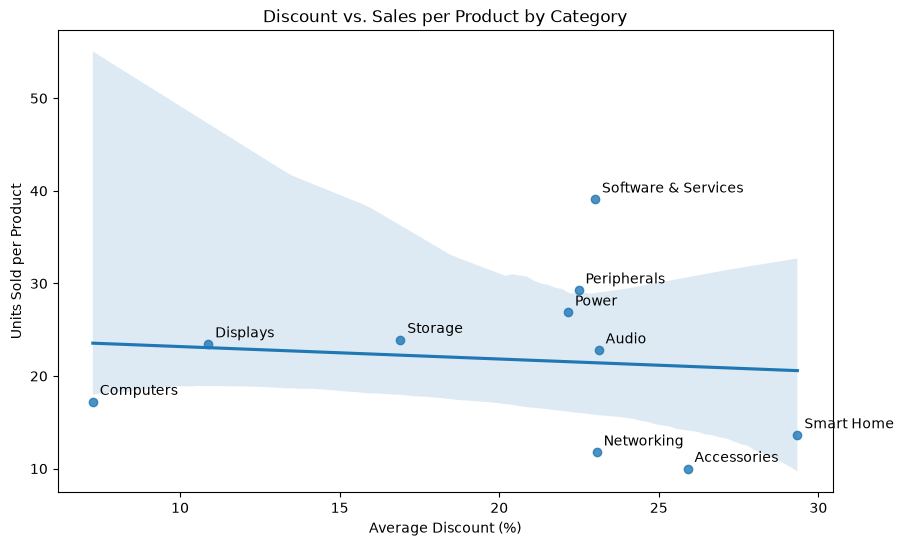

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

ax = sns.regplot(
    data=category_analysis,
    x="avg_discount",
    y="units_per_product"
)

# Add category labels
for _, row in category_analysis.iterrows():
    ax.annotate(
        row["category"],
        (row["avg_discount"], row["units_per_product"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Average Discount (%)")
plt.ylabel("Units Sold per Product")
plt.title("Discount vs. Sales per Product by Category")

plt.show()